In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold
import warnings
import sklearn
from scipy import stats
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import sklearn.model_selection as model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest,chi2

# 1.read CSV file

In [4]:
data = pd.read_csv('GuestSatisfactionPrediction.csv')

<ipython-input-4-85da83a9bf70>:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('GuestSatisfactionPrediction.csv')


In [5]:
data.shape

(8724, 69)

In [6]:

data.head()

,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,...,number_of_stays,first_review,last_review,review_scores_rating,requires_license,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification
0,21514496,https://www.airbnb.com/rooms/21514496,PRIVATE BEDROOM DOWNTOWN 2 BED/ 2 BATH #5,Beautiful 2 bedroom 2 bathroom furnished apart...,Each apartment is fully furnished and consists...,Beautiful 2 bedroom 2 bathroom furnished apart...,NaN,***Note that the pictures on the website may o...,NaN,NaN,...,2,11/17/2017,11/17/2017,80.0,f,f,f,strict_14_with_grace_period,f,f
1,990185,https://www.airbnb.com/rooms/990185,4 bed/2 ba Family Retreat in SD,We feel our house is a great place for a famil...,Our house is ideal for large families or group...,We feel our house is a great place for a famil...,Neighborhood Mira Mesa is a culturally diverse...,NaN,NaN,Our guests may use the BBQ grill.,...,26,8/2/2013,7/31/2019,97.0,f,f,f,moderate,f,f
2,19878244,https://www.airbnb.com/rooms/19878244,San Diego Dream Villa,"Zen, Luxury and the Best Location in Americas ...","San Diego Dream Villa, this unique and luxurio...","Zen, Luxury and the Best Location in Americas ...",This amazing house is located within a few min...,Im always available to make your trip experien...,"If you are bringing your car, remember that SD...",A couple of days before your arrival you will ...,...,170,7/23/2017,7/16/2019,98.0,f,f,f,strict_14_with_grace_period,f,f
3,24561458,https://www.airbnb.com/rooms/24561458,Studio with Piazza View in Downtown Little Italy,Start the day with breakfast on the sunny pati...,"Newly built, this beautiful studio is located ...",Start the day with breakfast on the sunny pati...,"Spend the day at the zoo in Balboa Park, or ex...",The apartment is located on the Piazza Della F...,"MTS, Train, and Trolly are close by. The airpo...",You will not be sharing the apartment with any...,...,212,5/1/2018,8/3/2019,98.0,f,t,f,moderate,f,f
4,32269829,https://www.airbnb.com/rooms/32269829,Beachside Retreat w/ Private Rooftop Deck w/ V...,This is a 2 bedroom/1 bathroom beachside unit...,Beach living at its finest! The highlight of ...,This is a 2 bedroom/1 bathroom beachside unit...,Mission Beach is an amazing coastal community ...,NaN,The Boardwalk and Bayside Walk are wonderful w...,This is a private home that is part of a typic...,...,2,6/30/2019,6/30/2019,100.0,f,t,f,strict_14_with_grace_period,f,f


In [7]:
data.columns

Index(['id', 'listing_url', 'name', 'summary', 'space', 'description',
       'neighborhood_overview', 'notes', 'transit', 'access', 'interaction',
       'house_rules', 'thumbnail_url', 'host_id', 'host_url', 'host_name',
       'host_since', 'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'street', 'neighbourhood',
       'neighbourhood_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet',
       'nightly_price', 'price_per_stay', 'security_deposit', 'cleaning_fee',
       'guests_included', 'extra_people', 'minimum_nights', 'maximum_nights',

In [8]:
data.describe()

,id,thumbnail_url,host_id,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,square_feet,guests_included,minimum_nights,maximum_nights,number_of_reviews,number_of_stays,review_scores_rating
count,8.724000e+03,0.0,8.724000e+03,0.0,8723.00000,8723.00000,8724.000000,8724.000000,8724.000000,8723.000000,8721.000000,8721.000000,106.000000,8724.000000,8724.000000,8724.000000,8724.000000,8724.000000,8724.000000
mean,2.061576e+07,NaN,7.217782e+07,NaN,36.63900,36.63900,32.767648,-117.181171,4.478450,1.477645,1.622176,2.383213,780.122642,2.385488,3.882164,612.218134,41.851674,83.703347,95.298945
std,1.022036e+07,NaN,7.192548e+07,NaN,148.16393,148.16393,0.063700,0.064124,2.966026,0.867093,1.172510,1.854677,581.604721,2.309945,13.271263,1532.434921,63.566724,127.133448,6.871417
min,6.000000e+00,NaN,2.900000e+01,NaN,0.00000,0.00000,32.531380,-117.281240,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,20.000000
25%,1.331246e+07,NaN,1.281344e+07,NaN,1.00000,1.00000,32.725623,-117.245445,2.000000,1.000000,1.000000,1.000000,500.000000,1.000000,1.000000,29.000000,5.000000,10.000000,94.000000
50%,2.122258e+07,NaN,4.407444e+07,NaN,2.00000,2.00000,32.756810,-117.168045,4.000000,1.000000,1.000000,2.000000,600.000000,1.000000,2.000000,365.000000,17.000000,34.000000,97.000000
75%,2.896445e+07,NaN,1.148944e+08,NaN,9.00000,9.00000,32.797730,-117.139930,6.000000,2.000000,2.000000,3.000000,1000.000000,3.000000,3.000000,1125.000000,52.000000,104.000000,100.000000
max,3.774504e+07,NaN,2.843016e+08,NaN,1737.00000,1737.00000,33.086070,-116.935990,24.000000,27.500000,10.000000,22.000000,3800.000000,24.000000,800.000000,99999.000000,641.000000,1282.000000,100.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Data columns (total 69 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                8724 non-null   int64  
 1   listing_url                       8724 non-null   object 
 2   name                              8724 non-null   object 
 3   summary                           8497 non-null   object 
 4   space                             7105 non-null   object 
 5   description                       8630 non-null   object 
 6   neighborhood_overview             6490 non-null   object 
 7   notes                             5215 non-null   object 
 8   transit                           5975 non-null   object 
 9   access                            6011 non-null   object 
 10  interaction                       6164 non-null   object 
 11  house_rules                       6754 non-null   object 
 12  thumbn

In [10]:
print(data.duplicated().sum())

0


# 2. Show NULL and fill it

In [11]:
print(data.isnull().sum())

id                                     0
listing_url                            0
name                                   0
summary                              227
space                               1619
                                    ... 
instant_bookable                       0
is_business_travel_ready               0
cancellation_policy                    0
require_guest_profile_picture          0
require_guest_phone_verification       0
Length: 69, dtype: int64


<Axes: >

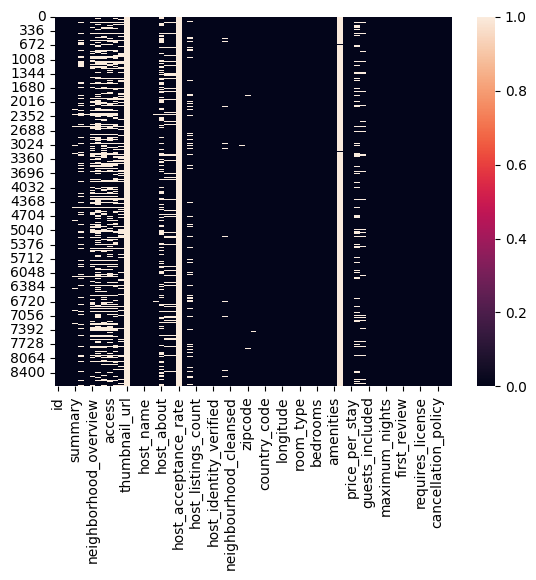

In [12]:
sns.heatmap(data.isnull())

In [13]:
missing_summary=(data.summary.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in summary is \t\t  :",missing_summary)

missing_space=(data.space.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in space is \t\t  :",missing_space)

missing_description=(data.description.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in description is \t  :",missing_description)

missing_neighborhood_overview=(data.neighborhood_overview.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in neighborhood_overview is :",missing_neighborhood_overview)

missing_notes=(data.notes.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in notes is \t\t  :",missing_notes)

missing_transit=(data.transit.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in transit is \t\t  :",missing_transit)

missing_access=(data.access.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in access is \t\t  :",missing_access)

missing_interaction=(data.interaction.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in interaction is \t  :",missing_interaction)

missing_house_rules=(data.house_rules.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in house_rules is \t  :",missing_house_rules)

missing_thumbnail_url=(data.thumbnail_url.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in thumbnail_url is \t  :",missing_thumbnail_url)

missing_host_location=(data.host_location.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_location is \t  :",missing_host_location)

missing_host_about=(data.host_about.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_about is \t\t  :",missing_host_about)

missing_host_response_time=(data.host_response_time.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_response_time is \t  :",missing_host_response_time)

missing_host_response_rate=(data.host_response_rate.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_response_rate is \t  :",missing_host_response_rate)

missing_host_acceptance_rate=(data.host_acceptance_rate.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_acceptance_rate is  :",missing_host_acceptance_rate)

missing_host_neighbourhood=(data.host_neighbourhood.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_neighbourhood is \t  :",missing_host_neighbourhood)

missing_neighbourhood =(data.neighbourhood .isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in neighbourhood is \t  :",missing_neighbourhood)

missing_zipcode=(data.zipcode.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in zipcode is \t\t  :",missing_zipcode)

missing_market=(data.market.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in market is \t\t  :",missing_market)

missing_square_feet=(data.square_feet.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in square_feet is \t  :",missing_square_feet)

missing_security_deposit=(data.security_deposit.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in security_deposit is \t  :",missing_security_deposit)

missing_cleaning_fee=(data.cleaning_fee.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in cleaning_fee is \t  :",missing_cleaning_fee)

The precentage of missing information in summary is 		  : 2.6020174232003668
The precentage of missing information in space is 		  : 18.558000917010546
The precentage of missing information in description is 	  : 1.0774873911049978
The precentage of missing information in neighborhood_overview is : 25.607519486474096
The precentage of missing information in notes is 		  : 40.22237505731316
The precentage of missing information in transit is 		  : 31.510774873911053
The precentage of missing information in access is 		  : 31.098120128381478
The precentage of missing information in interaction is 	  : 29.344337459880787
The precentage of missing information in house_rules is 	  : 22.58138468592389
The precentage of missing information in thumbnail_url is 	  : 100.0
The precentage of missing information in host_location is 	  : 0.16047684548372307
The precentage of missing information in host_about is 		  : 28.220999541494727
The precentage of missing information in host_response_time is 

In [14]:
((data.isnull().sum() / data.shape[0])*100).sort_values(ascending=False)

,0
thumbnail_url,100.000000
host_acceptance_rate,100.000000
square_feet,98.784961
notes,40.222375
transit,31.510775
...,...
instant_bookable,0.000000
is_business_travel_ready,0.000000
cancellation_policy,0.000000
require_guest_profile_picture,0.000000


In [15]:
#drop colomns
to_drop = [
    "thumbnail_url",       # 100% missing
    "host_acceptance_rate",# 100% missing
    "square_feet",         # 98.8% missing
    "name",
    "host_name",
    "id",
    "listing_url",
    "host_url",
    "host_id",

    "country_code",  #the same country
    "smart_location" #the same as of city + state
]
data = data.drop(columns=to_drop)

In [16]:
data['nightly_price'] = data['nightly_price'].replace('[\$,]', '', regex=True).astype(float)
data['price_per_stay'] = data['price_per_stay'].replace('[\$,]', '', regex=True).astype(float)
data['security_deposit'] = data['security_deposit'].replace('[\$,]', '', regex=True).astype(float)
data['cleaning_fee'] = data['cleaning_fee'].replace('[\$,]', '', regex=True).astype(float)
data['extra_people'] = data['extra_people'].replace('[\$,]', '', regex=True).astype(float)

In [17]:
data['host_response_rate'] = data['host_response_rate'].replace('[\%,]', '', regex=True).astype(float)

In [18]:
data['first_review'] = pd.to_datetime(data['first_review'], errors='coerce')
data['first_review'] = (pd.to_datetime("today") - data['first_review']).dt.days / 365
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')
data['last_review'] = (pd.to_datetime("today") - data['last_review']).dt.days / 365
data['host_since'] = pd.to_datetime(data['host_since'], errors='coerce')
data['host_since'] = (pd.to_datetime("today") - data['host_since']).dt.days / 365

In [19]:
data['zipcode'] = data['zipcode'].replace('-', '', regex=True).astype(float)

In [20]:
# fill by median
meadian_cols=['beds','bathrooms','bedrooms','cleaning_fee','security_deposit','host_total_listings_count','host_listings_count','host_response_rate','host_since']
data[meadian_cols]=data[meadian_cols].fillna(data[meadian_cols].median())

In [21]:
data['city'] = data['city'].str.split(',', expand=True)[0]

#fill by median of the same city
data['zipcode']=data['zipcode'].fillna(data.groupby(['city'])['zipcode'].transform('median'))

In [22]:
#fill by mode
cols_to_mode = ['host_response_time','neighbourhood','market','host_location','host_neighbourhood','host_identity_verified','host_has_profile_pic','host_is_superhost']
for col in cols_to_mode:
    if data[col].mode().empty:
        data[col] = data[col].fillna('Unknown')
    else:
        mode_val = data[col].mode()[0]
        data[col] = data[col].fillna(mode_val)


In [23]:
#fill be valy refer to it
null_idx = data.index[data['state'].isna()]
# print(null_idx)
# print(data['state'][null_idx])
data['state'][null_idx]=data['street'][null_idx].str.split(',', expand=True)[0]
# print(data['state'][null_idx])
data = data.drop(columns="street")    #the same of city + state + country

<ipython-input-23-a9b95fba7e0b>:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['state'][null_idx]=data['street'][null_idx].str.split(',', expand=True)[0]
<ipython-input-23-a9b95fba7e0b>:5: SettingWithCopyWarning: 
A value is trying to

In [24]:
missing_cleaning_beds=(data.beds.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information after fill in cleaning_beds is \t  :",missing_cleaning_beds)
missing_cleaning_bathrooms=(data.bathrooms.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information after fill in bathrooms is \t  :",missing_cleaning_bathrooms)
missing_nightly_price=(data.nightly_price.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information after fill in nightly_price is \t  :",missing_nightly_price)

print("The precentage of missing information after fill in host_response_time is \t  :",(data.host_response_time.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in neighbourhood is \t  :",(data.neighbourhood.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in state  is \t  :",(data.state.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in market  is \t  :",(data.market.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in host_location  is \t  :",(data.host_location.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in host_neighbourhood  is \t  :",(data.host_neighbourhood.isnull().sum() / data.shape[0]) * 100)


The precentage of missing information after fill in cleaning_beds is 	  : 0.0
The precentage of missing information after fill in bathrooms is 	  : 0.0
The precentage of missing information after fill in nightly_price is 	  : 0.0
The precentage of missing information after fill in host_response_time is 	  : 0.0
The precentage of missing information after fill in neighbourhood is 	  : 0.0
The precentage of missing information after fill in state  is 	  : 0.0
The precentage of missing information after fill in market  is 	  : 0.0
The precentage of missing information after fill in host_location  is 	  : 0.0
The precentage of missing information after fill in host_neighbourhood  is 	  : 0.0


# 3. Check outliers in data and identify it

In [25]:
numerical_cols = data.select_dtypes(include='number').columns
plot_cols=numerical_cols.difference(['zipcode'])
numerical_cols = numerical_cols.difference(['review_scores_rating'])

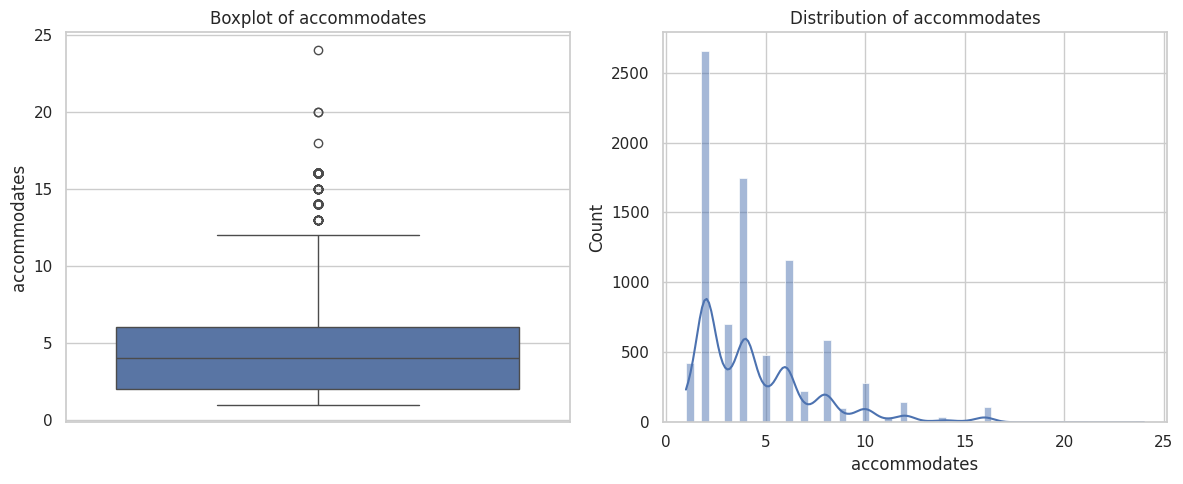

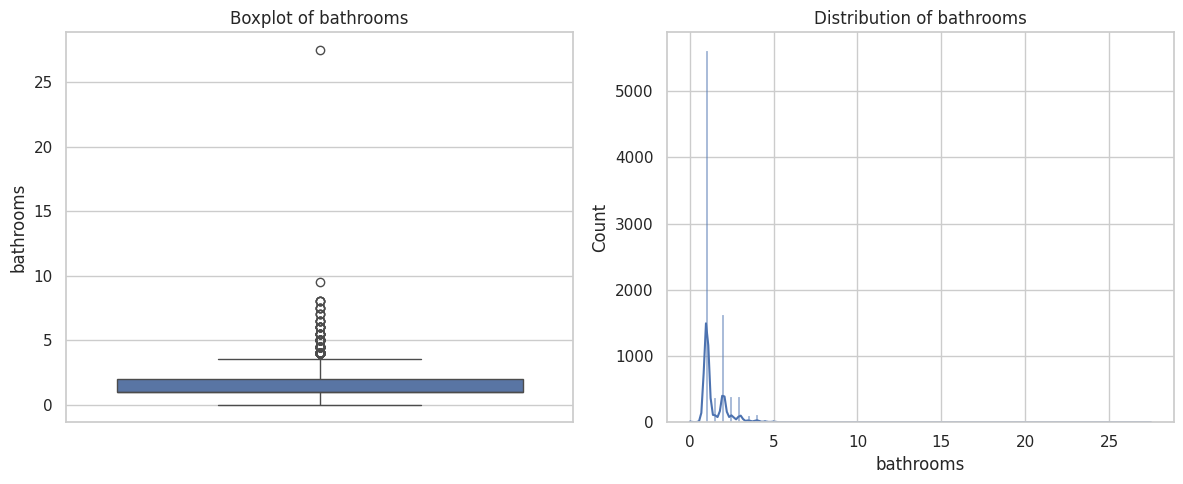

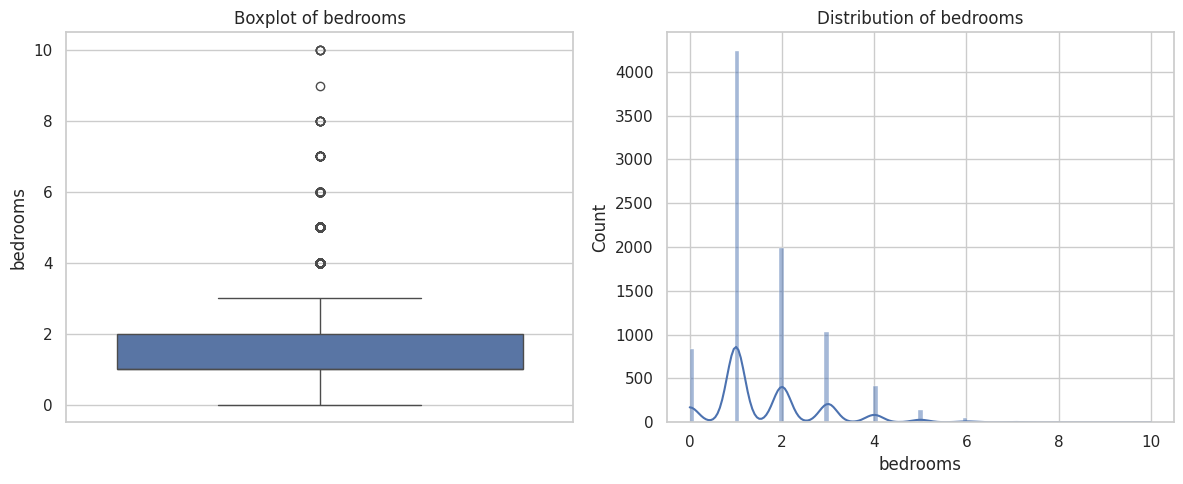

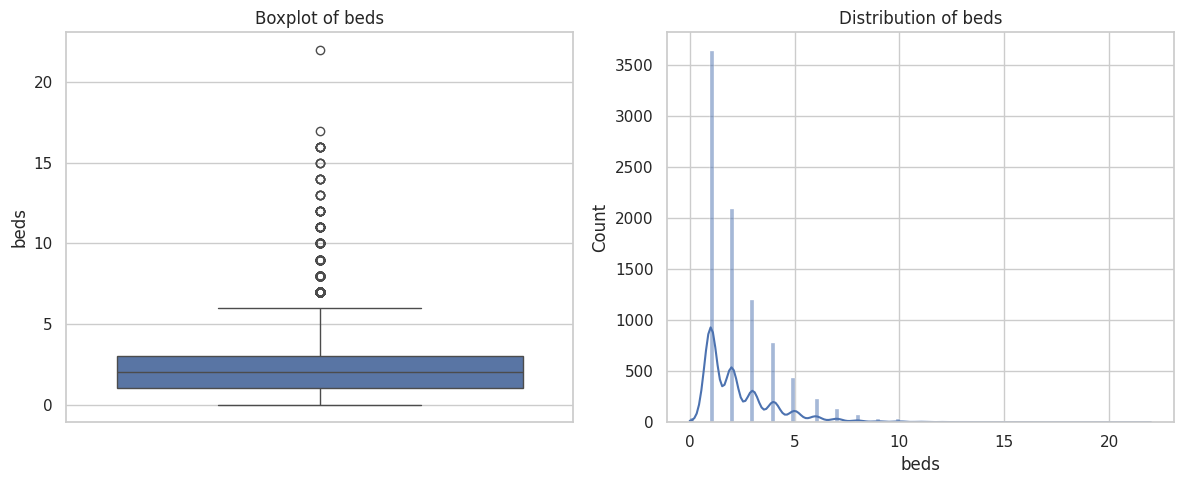

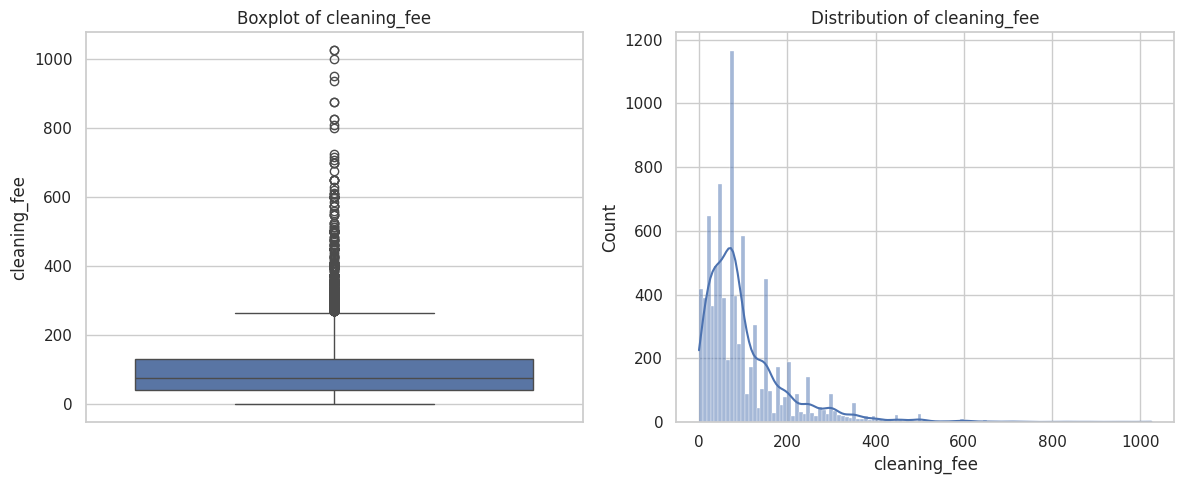

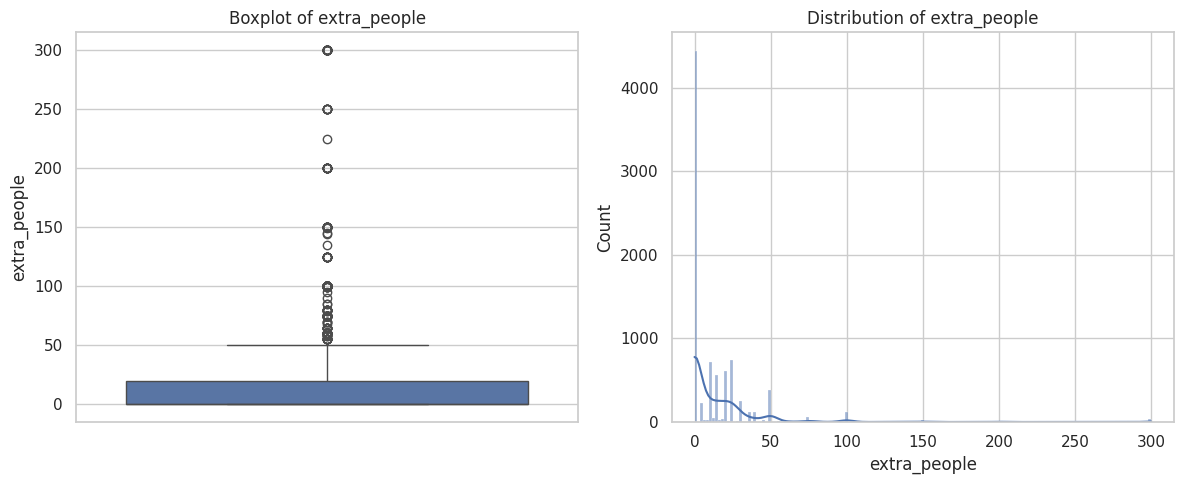

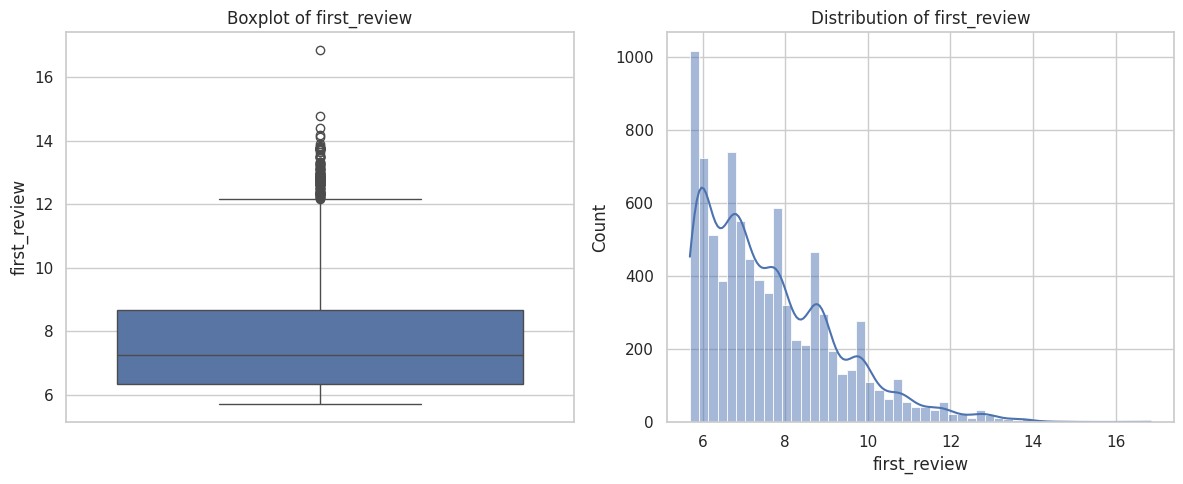

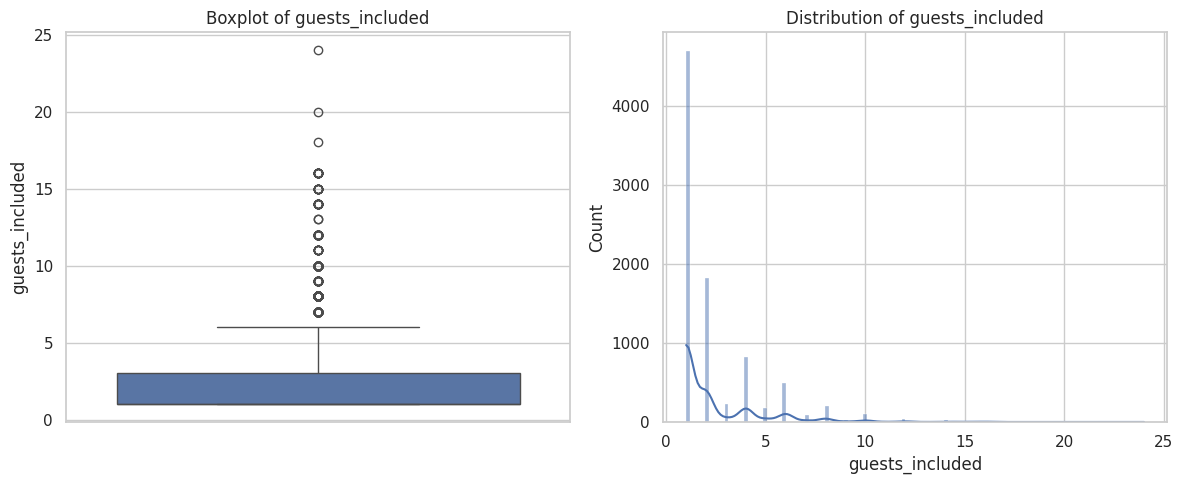

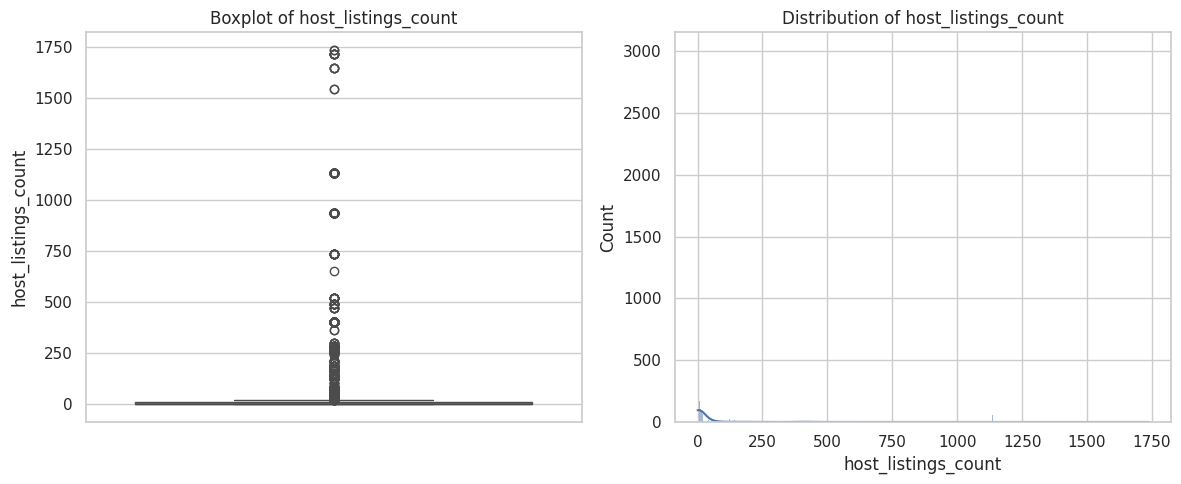

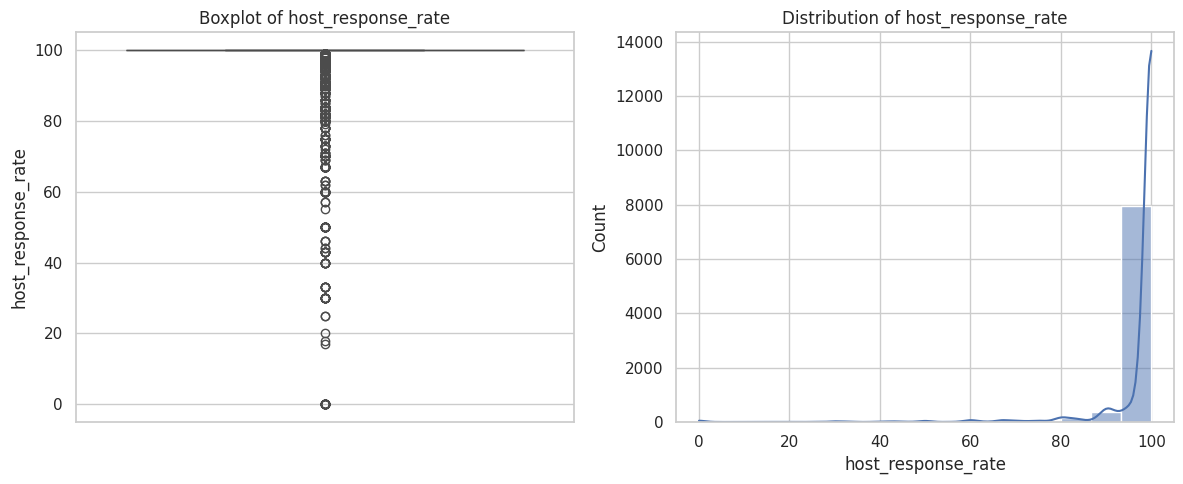

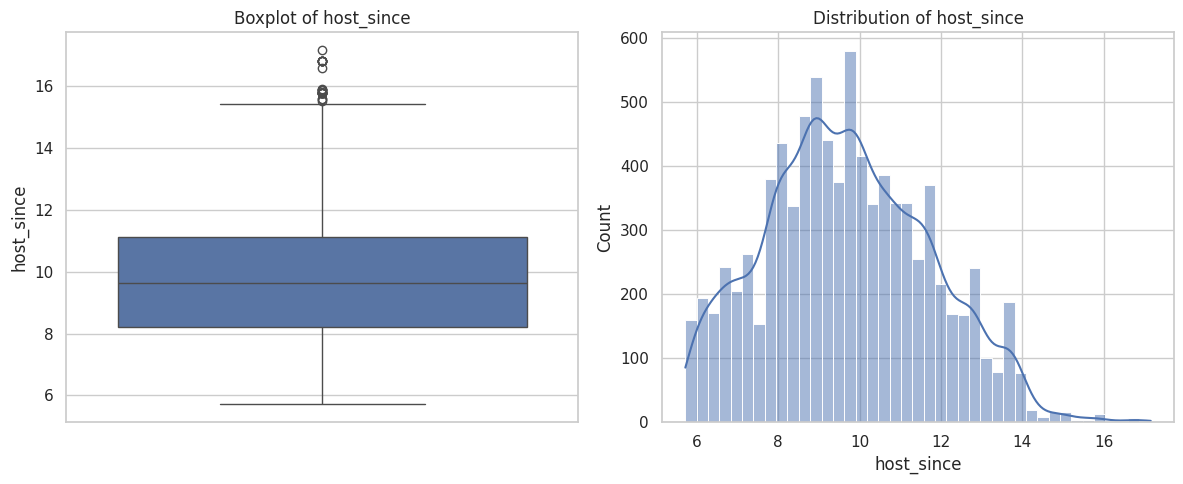

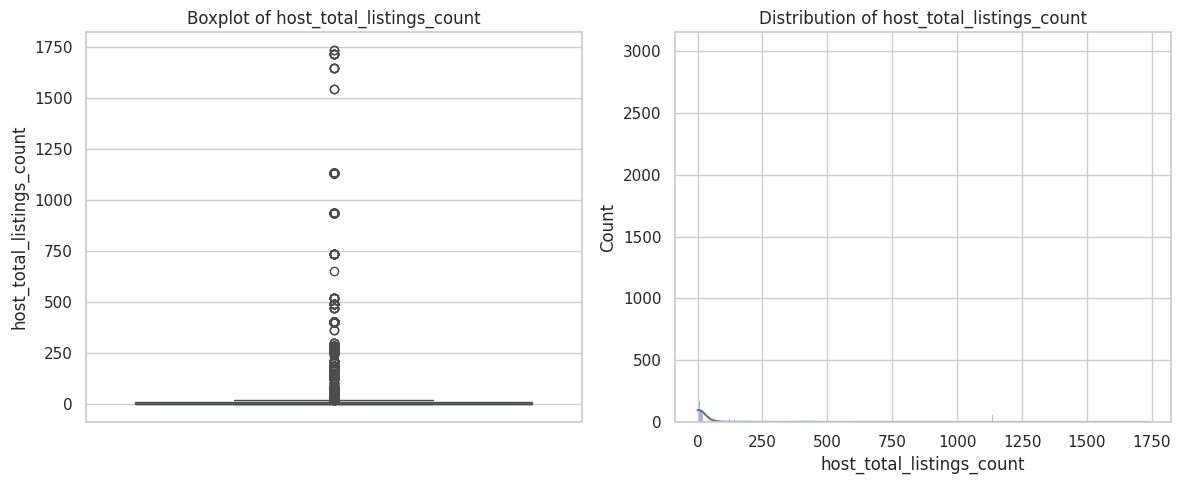

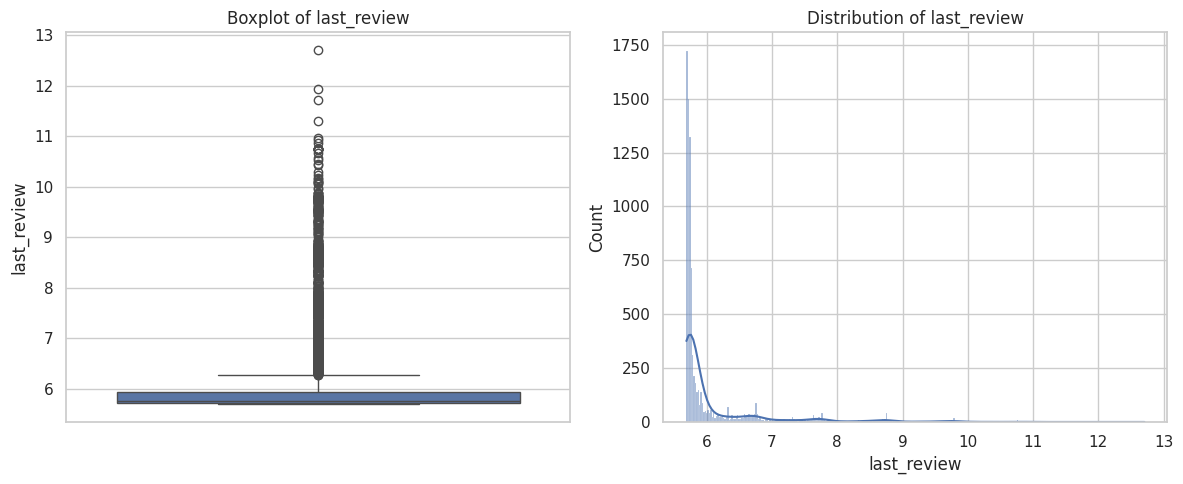

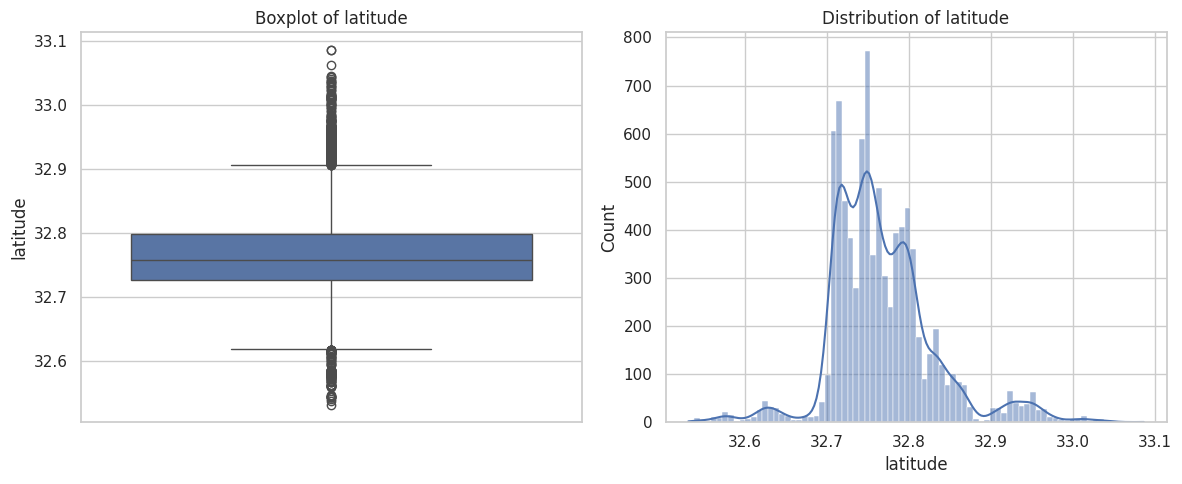

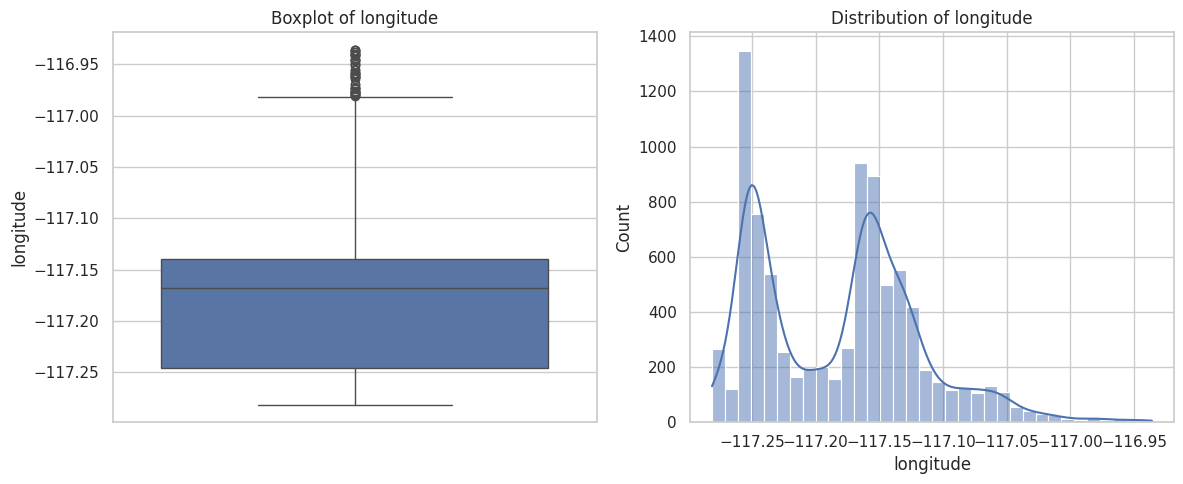

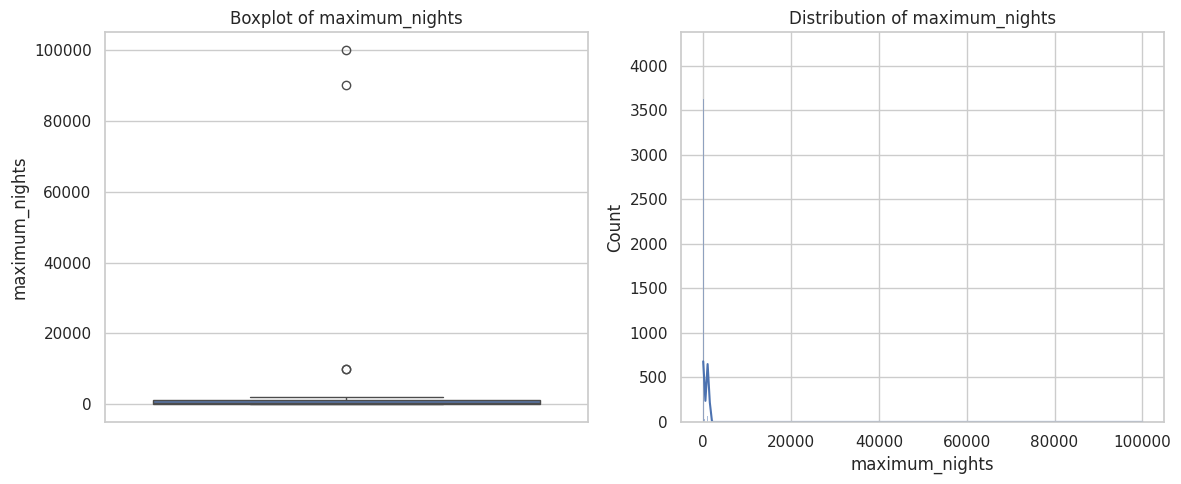

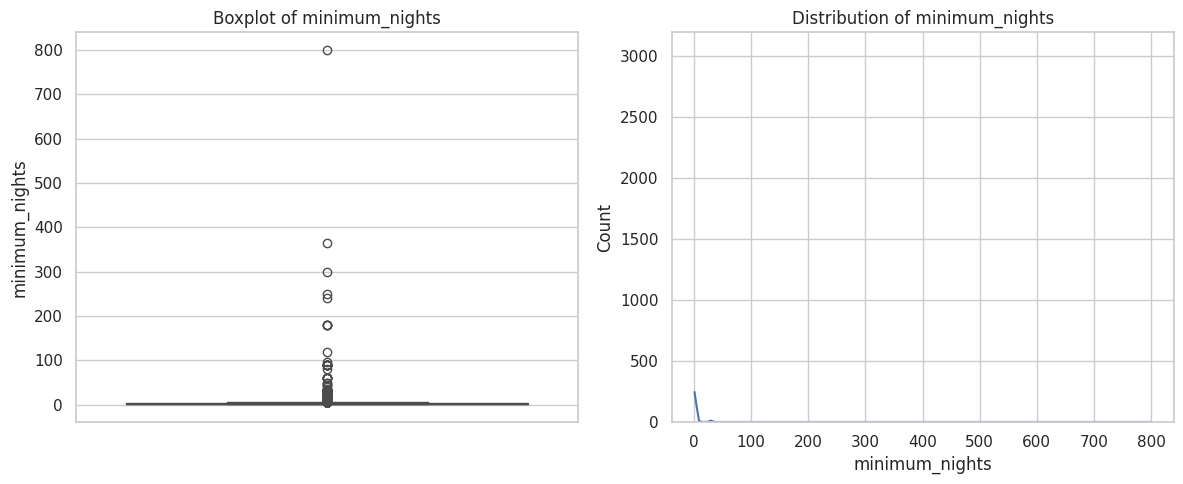

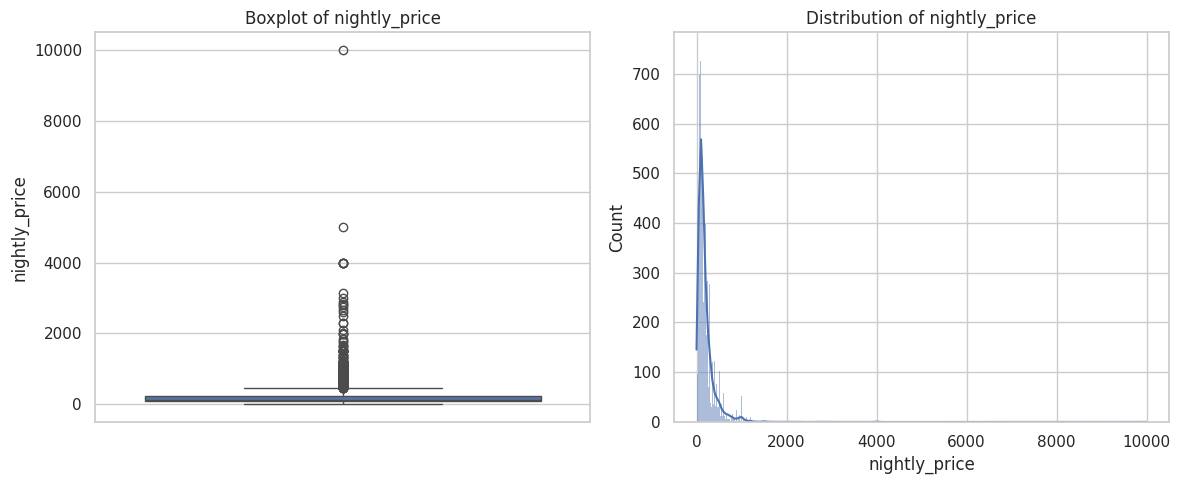

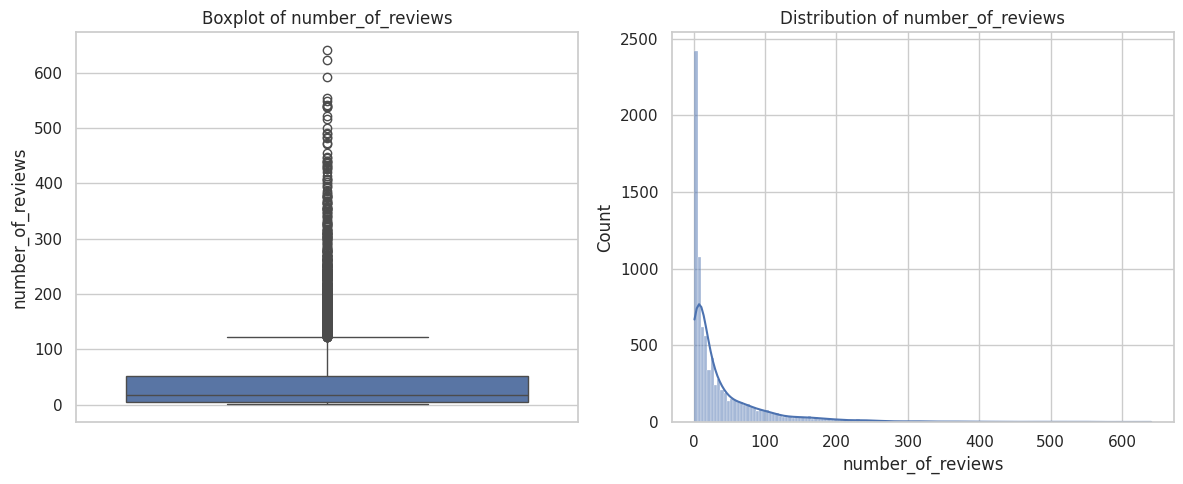

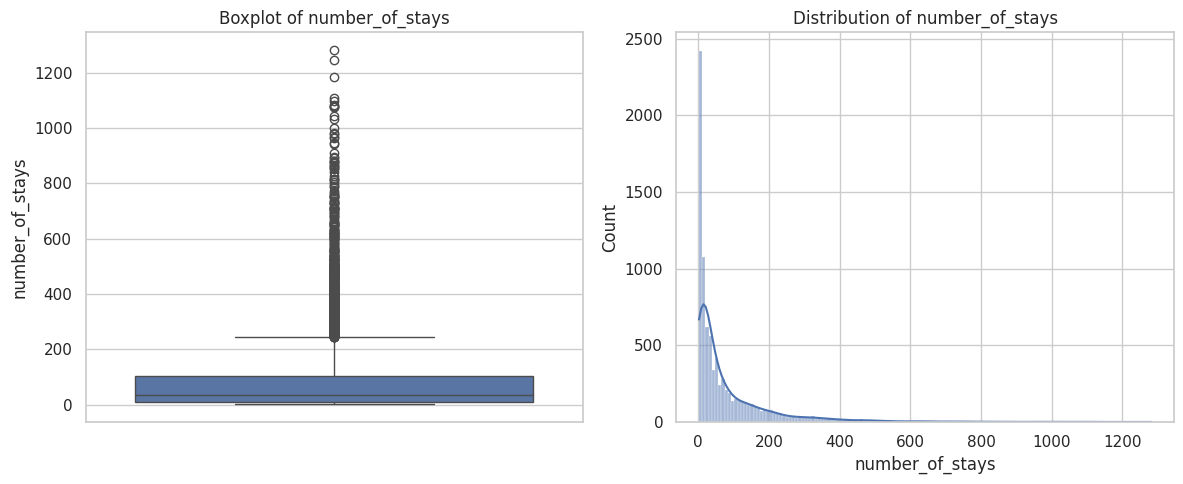

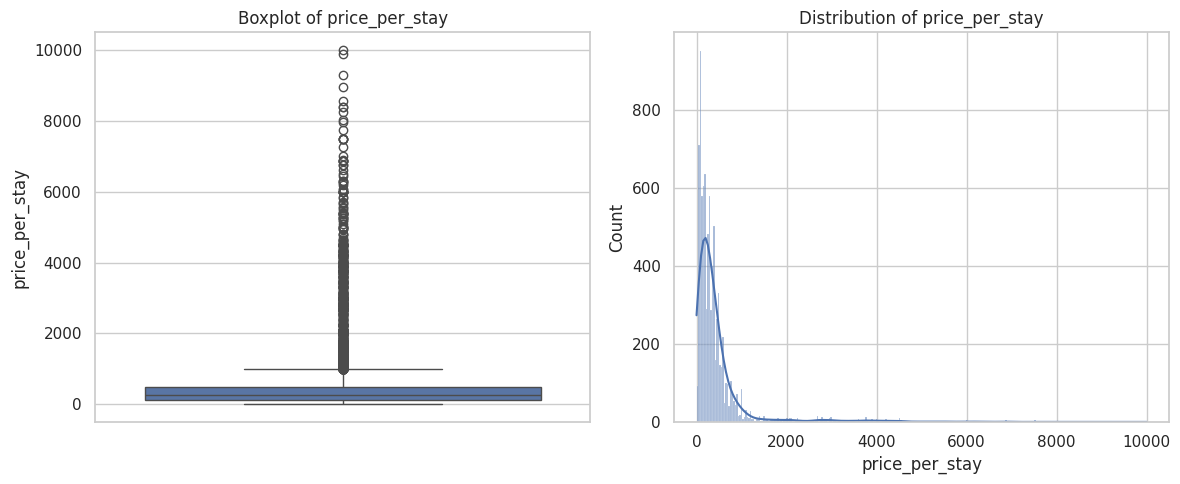

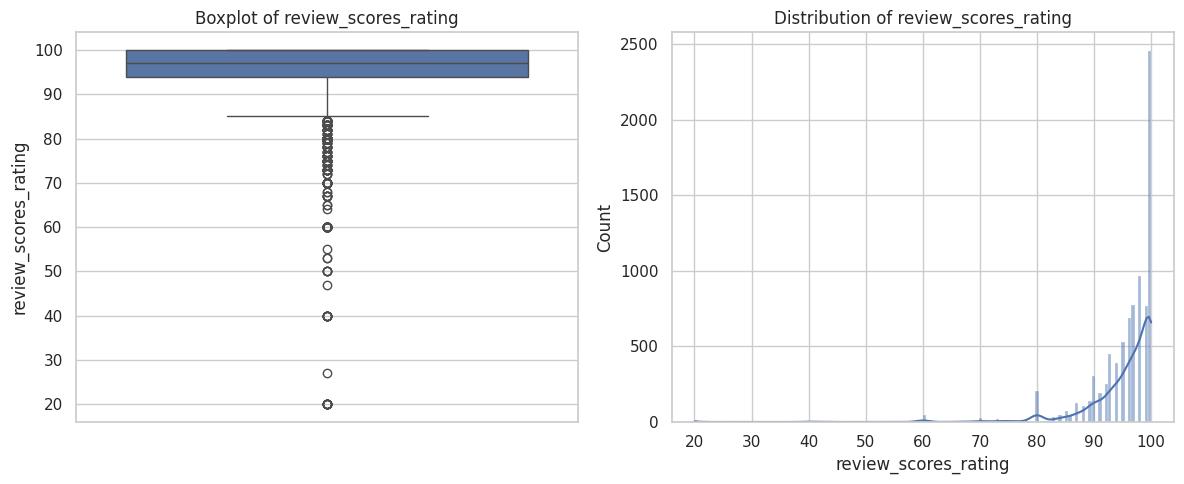

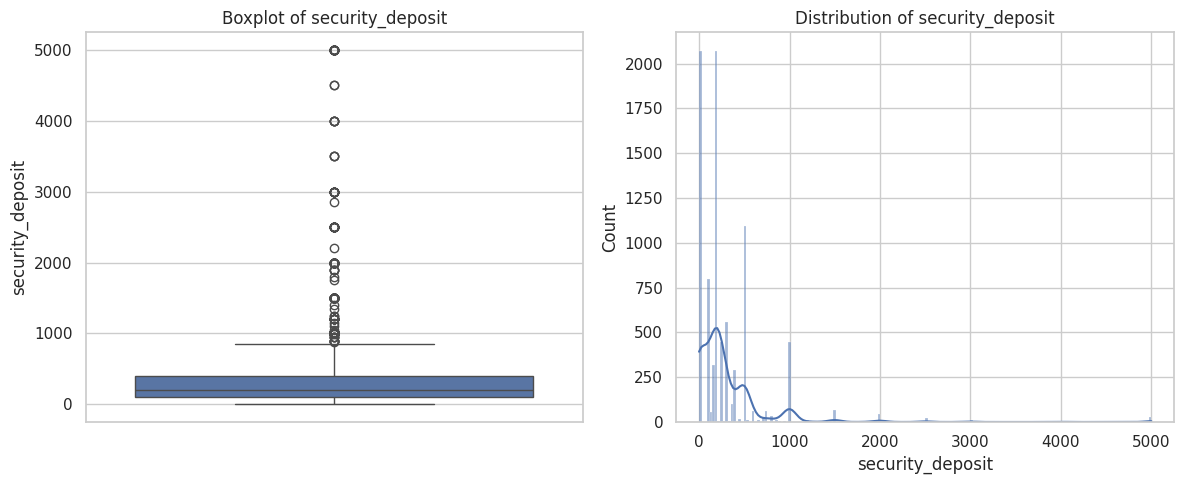

In [26]:
# Set style
sns.set(style="whitegrid")

# Create plots
for col in plot_cols:
    plt.figure(figsize=(12, 5))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')

    # Distplot
    plt.subplot(1, 2, 2)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.tight_layout()
    plt.show()

In [27]:
for col in numerical_cols:
    # calculate interquartile range
    q25, q75 = np.percentile(data[col], 25), np.percentile(data[col], 75)
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off
    # identify outliers
    outliers = ( ( data[col] < lower) | (data[col] > upper) )
    index_label = data[outliers].index
    print(f'Number of outliers in {col}: {len(index_label)}')
   # ds.drop(index_label, inplace=True)

Number of outliers in accommodates: 179
Number of outliers in bathrooms: 219
Number of outliers in bedrooms: 627
Number of outliers in beds: 317
Number of outliers in cleaning_fee: 575
Number of outliers in extra_people: 318
Number of outliers in first_review: 125
Number of outliers in guests_included: 504
Number of outliers in host_listings_count: 1301
Number of outliers in host_response_rate: 1700
Number of outliers in host_since: 25
Number of outliers in host_total_listings_count: 1301
Number of outliers in last_review: 1635
Number of outliers in latitude: 521
Number of outliers in longitude: 46
Number of outliers in maximum_nights: 4
Number of outliers in minimum_nights: 629
Number of outliers in nightly_price: 687
Number of outliers in number_of_reviews: 755
Number of outliers in number_of_stays: 755
Number of outliers in price_per_stay: 653
Number of outliers in security_deposit: 671
Number of outliers in zipcode: 1458


In [28]:
# num_col = (ds.columns).to_list()
# num_col = num_col[0:]

def outliers(ds, column):
    Q1 = ds[column].quantile(0.25)
    Q3 = ds[column].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    for i in range(len(ds)):
        if ds[column].iloc[i] > upper_bound:
            ds[column].iloc[i] = upper_bound
        if ds[column].iloc[i] < lower_bound:
            ds[column].iloc[i] = lower_bound

for feature in numerical_cols:
    outliers(data, feature)


Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ds[column].iloc[i] = lower_bound
<ipython-input-28-0d262933142b>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = lower_bound
<ipython-input-28-0d262933142b>:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are 

In [29]:
for col in numerical_cols:
    # calculate interquartile range
    q25, q75 = np.percentile(data[col], 25), np.percentile(data[col], 75)
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off
    # identify outliers
    outliers = ( ( data[col] < lower) | (data[col] > upper) )
    index_label = data[outliers].index
    print(f'Number of outliers in {col}: {len(index_label)}')
   # ds.drop(index_label, inplace=True)

Number of outliers in accommodates: 0
Number of outliers in bathrooms: 0
Number of outliers in bedrooms: 0
Number of outliers in beds: 0
Number of outliers in cleaning_fee: 0
Number of outliers in extra_people: 0
Number of outliers in first_review: 0
Number of outliers in guests_included: 0
Number of outliers in host_listings_count: 0
Number of outliers in host_response_rate: 0
Number of outliers in host_since: 0
Number of outliers in host_total_listings_count: 0
Number of outliers in last_review: 0
Number of outliers in latitude: 0
Number of outliers in longitude: 0
Number of outliers in maximum_nights: 0
Number of outliers in minimum_nights: 0
Number of outliers in nightly_price: 0
Number of outliers in number_of_reviews: 0
Number of outliers in number_of_stays: 0
Number of outliers in price_per_stay: 0
Number of outliers in security_deposit: 0
Number of outliers in zipcode: 0


# 3. Encoding Data

In [30]:
data.dtypes.value_counts()

,count
object,33
float64,19
int64,5


In [31]:
data['host_is_superhost'] = data['host_is_superhost'].map({'f': 0, 't': 1})
data['host_has_profile_pic'] = data['host_has_profile_pic'].map({'f': 0, 't': 1})
data['host_identity_verified'] = data['host_identity_verified'].map({'f': 0, 't': 1})
data['is_location_exact'] = data['is_location_exact'].map({'f': 0, 't': 1})
data['requires_license'] = data['requires_license'].map({'f': 0, 't': 1})
data['instant_bookable'] = data['instant_bookable'].map({'f': 0, 't': 1})
data['is_business_travel_ready'] = data['is_business_travel_ready'].map({'f': 0, 't': 1})
data['require_guest_profile_picture'] = data['require_guest_profile_picture'].map({'f': 0, 't': 1})
data['require_guest_phone_verification'] = data['require_guest_phone_verification'].map({'f': 0, 't': 1})

In [32]:
data.dtypes.value_counts()

,count
object,24
float64,19
int64,14


In [33]:
uniq= data['host_response_time'].unique()
print(uniq)

['within a few hours' 'within an hour' 'a few days or more' 'within a day']


In [34]:
uniq= data['host_neighbourhood'].unique()
print(uniq)

['Pacific Beach' 'Mira Mesa' 'Hillcrest' 'Little Italy' 'La Jolla'
 'Kensington' 'Birdland' 'Cherokee Point' 'Marina' 'Core-Columbia'
 'Talmadge' 'Pike Place Market' 'Castle' 'Cannes' 'East Village' 'Gaslamp'
 'Clairemont Mesa East' 'Point Loma Heights' 'Linda Vista' 'North Park'
 'Park West' 'Midtown' 'Mission Valley East' 'Ocean Beach'
 'North Clairemont' 'Mission Beach' 'Redwood Village/Rolando Park'
 'Bay Ho' 'University City' 'Anaheim' 'Downtown' 'Mount Hope'
 'Adams North' 'Cortez' 'Logan Heights' 'Golden Hill' 'Morena'
 'Grant Hill' 'South Park' 'Bay Park' 'Paradise Hills' 'Little Havana'
 'Scripps Ranch' 'Loma Portal' 'Rancho Penasquitos' 'Colina Del Sol'
 'Normal Heights' 'Carmel Valley' 'Gay Village' 'Roseville/Fleet Ridge'
 'College East' 'Bay Terraces' 'Midway District' 'Del Mar Heights'
 'Fairmont Village' 'Mission Hill' 'Grantville' 'LoDo' 'Incline Village'
 'Central City' 'Encanto' 'University Heights' 'Rolando' 'Sunset Cliffs'
 'San Clemente' 'Azalea/Hollywood Park' 'Sh

In [35]:
uniq= data['country'].unique()
print(uniq)

['United States' 'Mexico' 'United Kingdom']


In [36]:
uniq= data['room_type'].unique()
print(uniq)

['Private room' 'Entire home/apt' 'Shared room']


In [37]:
uniq= data['bed_type'].unique()
print(uniq)

['Real Bed' 'Couch' 'Pull-out Sofa' 'Futon' 'Airbed']


In [38]:
uniq= data['state'].unique()
print(uniq)

['CA' 'Baja California' 'California' 'Ca' 'B.C.' 'WA']


In [39]:
uniq= data['cancellation_policy'].unique()
print(uniq)

['strict_14_with_grace_period' 'moderate' 'strict' 'super_strict_60'
 'flexible' 'super_strict_30']


In [40]:
uniq= data['neighbourhood'].unique()
print(uniq)

['East Village' 'Mira Mesa' 'Hillcrest' 'Little Italy' 'Mission Beach'
 'Kensington' 'Pacific Beach' 'Birdland' 'Cherokee Point' 'Marina'
 'Core-Columbia' 'Talmadge' 'La Jolla' 'Castle' 'Adams North'
 'Mission Hill' 'Paradise Hills' 'North Park' 'Gaslamp'
 'Clairemont Mesa East' 'Linda Vista' 'Ocean Beach' 'Park West' 'Midtown'
 'Mission Valley East' 'Redwood Village/Rolando Park' 'Bay Ho'
 'University City' 'Sherman Heights' 'Mount Hope' 'Mountain View'
 'Logan Heights' 'Golden Hill' 'Loma Portal' 'Stockton' 'South Park'
 'Bay Park' 'Morena' 'Point Loma Heights' 'Scripps Ranch' 'Carmel Valley'
 'Rancho Penasquitos' 'Colina Del Sol' 'Normal Heights'
 'Roseville/Fleet Ridge' 'College East' 'Bay Terraces' 'Midway District'
 'Del Mar Heights' 'Fairmont Village' 'Grantville' 'Encanto'
 'University Heights' 'Rolando' 'Sunset Cliffs' 'Azalea/Hollywood Park'
 'Oak Park' 'Burlingame' 'Chollas View' 'Rancho Bernardo' 'Horton Plaza'
 'Teralta West' 'Grant Hill' 'College West' 'North Clairemont' 

In [41]:
uniq= data['neighbourhood_cleansed'].unique()
print(uniq)

['East Village' 'Mira Mesa' 'Midtown' 'Little Italy' 'Mission Bay'
 'Kensington' 'Pacific Beach' 'Bird Land' 'City Heights West' 'Marina'
 'Cortez Hill' 'Talmadge' 'La Jolla' 'Normal Heights' 'Old Town'
 'Northwest' 'Paradise Hills' 'North Hills' 'Gaslamp Quarter'
 'Clairemont Mesa' 'Linda Vista' 'Ocean Beach' 'Bonita Long Canyon'
 'Mission Valley' 'Darnall' 'Bay Ho' 'University City' 'Grant Hill'
 'Mount Hope' 'Mountain View' 'Memorial' 'Balboa Park' 'Loma Portal'
 'Bay Park' 'South Park' 'Moreno Mission' 'Park West' 'Scripps Ranch'
 'Carmel Valley' 'Rancho Penasquitos' 'City Heights East' 'Roseville'
 'College Area' 'Bay Terrace' 'Midtown District' 'Core' 'Del Mar Heights'
 'Grantville' 'North City' 'Otay Ranch' 'Encanto'
 'West University Heights' 'Rolando' 'Wooded Area' 'Chollas View'
 'Rancho Bernadino' 'Torrey Pines' 'North Clairemont' 'La Jolla Village'
 'Emerald Hills' 'Nestor' 'San Carlos' 'Lake Murray' 'Columbia'
 'Tierrasanta' 'Serra Mesa' 'Sorrento Valley' 'Thomy Locust Pl'

In [42]:
uniq= data['property_type'].unique()
print(uniq)

['Apartment' 'House' 'Bungalow' 'Guest suite' 'Condominium' 'Cottage'
 'Villa' 'Townhouse' 'Guesthouse' 'Other' 'Loft' 'Resort'
 'Casa particular (Cuba)' 'Boat' 'Hostel' 'Tiny house' 'Bed and breakfast'
 'Serviced apartment' 'Camper/RV' 'Boutique hotel' 'Aparthotel' 'Campsite'
 'Farm stay' 'Igloo' 'Hotel' 'Cabin' 'Castle' 'Cave' 'Earth house'
 'Treehouse' 'Bus' 'Dome house' 'Tent' 'Chalet' 'Nature lodge'
 'Vacation home']


In [43]:
uniq= data['market'].unique()
print(uniq)

['San Diego' 'Carlsbad' 'Other (Domestic)' 'Tijuana' 'Los Angeles'
 'Temecula Valley']


In [44]:
uniq= data['city'].unique()
print(uniq)

['San Diego' 'La Jolla' 'Chula Vista' 'San diego' 'San Diego ' 'Del Mar'
 'La Mesa' 'LA JOLLA' 'Mission Beach' 'Solana Beach' 'Tijuana' 'SAN DIEGO'
 'La Jolla ' 'Poway' 'Ocean Beach' 'La Jolla Cove' 'Escondido'
 'Lemon Grove' 'Alpine' 'Chula Vista (Eastlake)' 'San Ysidro' 'CA'
 'La jolla' 'Santee' 'National City' 'University heights' 'Irvine'
 'Bonita' 'Gas lamp San Diego' 'San DIego' ' La Jolla'
 'Del Mar Highlands ' 'San Deigo' 'San Diego County' 'Mission Bay'
 'La Jolla Shores']


In [45]:
data['city'].str.split(',', expand=True)[0].unique()

array(['San Diego', 'La Jolla', 'Chula Vista', 'San diego', 'San Diego ',
       'Del Mar', 'La Mesa', 'LA JOLLA', 'Mission Beach', 'Solana Beach',
       'Tijuana', 'SAN DIEGO', 'La Jolla ', 'Poway', 'Ocean Beach',
       'La Jolla Cove', 'Escondido', 'Lemon Grove', 'Alpine',
       'Chula Vista (Eastlake)', 'San Ysidro', 'CA', 'La jolla', 'Santee',
       'National City', 'University heights', 'Irvine', 'Bonita',
       'Gas lamp San Diego', 'San DIego', ' La Jolla',
       'Del Mar Highlands ', 'San Deigo', 'San Diego County',
       'Mission Bay', 'La Jolla Shores'], dtype=object)

In [46]:
#Encoding city
codes = {
    'chula vista':    0,
    'del mar':        1,
    'escondido':      2,
    'la jolla':       3,
    'mission beach':  4,
    'san diego':      5,
}

# 2) apply in one pass: look for each key substring, else default to 6
data['city'] = (
    data['city']
      .str.lower()
      .apply(lambda x: next((c for k,c in codes.items() if k in x), 6))
)

In [47]:
uniq= data['host_location'].unique()
print(uniq)

['San Diego, California, United States' 'US'
 'Brawley, California, United States' 'Seattle, Washington, United States'
 'Los Angeles, California, United States'
 'Salt Lake City, Utah, United States'
 'Laguna Niguel, California, United States'
 'Lemon Grove, California, United States' 'California, United States'
 'Jersey City, New Jersey, United States'
 'San Francisco, California, United States' 'Colorado, United States'
 'Henderson, Nevada, United States'
 'Chula Vista, California, United States'
 'West Hollywood, California, United States'
 'Del Mar, California, United States'
 'New Rochelle, New York, United States'
 'New York, New York, United States' 'Denver, Colorado, United States'
 'San Antonio, Texas, United States' 'United States' 'UNITED STATES'
 'Arlington, Texas, United States' 'New Orleans, Louisiana, United States'
 'Spring Valley, California, United States'
 'Portland, Oregon, United States' 'Escondido, California, United States'
 'Temecula, California, United States'

In [48]:
# data['country_code'] = data['country_code'].map({'US': 0, 'MX': 1, 'GB': 2})
data['country'] = data['country'].map({'United States': 0, 'Mexico': 1, 'United Kingdom': 2})
data['host_response_time'] = data['host_response_time'].map({'within a few hours': 0, 'within an hour': 1, 'a few days or more': 2,'within a day': 3})
data['room_type'] = data['room_type'].map({ 'Entire home/apt': 0,'Private room': 1,  'Shared room': 2})
data['bed_type'] = data['bed_type'].map({'Real Bed': 0, 'Couch': 1, 'Pull-out Sofa': 2,'GB': 3,'Futon': 4,'Airbed': 5})
data['state'] = data['state'].map({ 'CA': 0,'Baja California': 1,  'California': 0,'Ca': 0,'B.C.': 2,'WA': 3})
data['market'] = data['market'].map({ 'San Diego': 0,'Carlsbad': 1,  'CA': 2,'Other (Domestic)': 3,'Tijuana': 4,'Los Angeles': 5,'Temecula Valley': 6})
data['cancellation_policy'] = data['cancellation_policy'].map({'strict_14_with_grace_period': 0, 'moderate': 1, 'strict': 2,'super_strict_60': 3,'flexible': 4,'super_strict_30': 5})

In [49]:
# encoding_col = ['country','host_response_time','room_type','bed_type','state','market','cancellation_policy']
# for col in encoding_col:
#     data[col], uniques = pd.factorize(data[col])
#     mapping = dict(enumerate(uniques))


In [50]:
data.dtypes.value_counts()

,count
int64,22
float64,19
object,16


# 4. Factorize  Encoding

In [51]:
categorical_columns = [
    'host_neighbourhood',
    'host_location',
    'property_type',
    'neighbourhood_cleansed',
    'neighbourhood'
]

In [52]:
mappings = {}

# 4. Loop through and factorize
for col in categorical_columns:
    # a) Fill missing
    data[col] = data[col].fillna('missing').astype(str)

    # b) Factorize returns (labels array, uniques Index)
    labels, uniques = pd.factorize(data[col])

    # c) Replace the column with its integer codes
    data[col] = labels

    # d) Store the reverse mapping: code -> original category
    mappings[col] = dict(enumerate(uniques))


In [53]:
# data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)
# data_encoded.shape, data_encoded.head()

In [54]:
# data = pd.concat([data.reset_index(drop=True), data_encoded.reset_index(drop=True)], axis=1)

In [55]:
# data = data.drop(columns=categorical_columns)

In [56]:
data.dtypes.value_counts()

,count
int64,27
float64,19
object,11


#  5. Encoding  text column data by (TF-IDF)

In [57]:
text_columns = ['summary', 'space', 'description', 'neighborhood_overview',
                'notes', 'transit', 'access', 'interaction', 'house_rules','host_about','amenities']

# Fill NaNs and optionally combine them into a single column
data['combined_text'] = data[text_columns].fillna('').agg(' '.join, axis=1)
data = data.drop(columns=text_columns) # drop text columns

In [58]:
# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)  # customize features

# Fit and transform the text
tfidf_matrix = vectorizer.fit_transform(data['combined_text'])

# Convert to DataFrame (optional)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

In [59]:
data = pd.concat([data.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

In [60]:
data = data.drop(columns="combined_text")

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Columns: 546 entries, host_since to zoo
dtypes: float64(519), int64(27)
memory usage: 36.3 MB


In [62]:
data.dtypes.value_counts()

,count
float64,519
int64,27


In [63]:
print(data.isnull().sum())

host_since            0
host_location         0
host_response_time    0
host_response_rate    0
host_is_superhost     0
                     ..
world                 0
yard                  0
year                  0
years                 0
zoo                   0
Length: 546, dtype: int64


# Feather Selection

---







# correlation









In [64]:
# corr = data.corr()
# fig, ax = plt.subplots(figsize=(70, 70))
# sns.heatmap(corr,annot = True, ax =ax)

In [65]:
# corr_values = {}
# top_feature = corr.index[abs(corr['review_scores_rating'])>0.05]
# print(top_feature)
# print(len(top_feature))
# plt.subplots(figsize=(12, 8))
# top_corr = data[top_feature].corr()
# sns.heatmap(top_corr, annot=True)
# plt.show()

In [66]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split

# X = data.drop(['review_scores_rating'], axis=1)
# y = data['review_scores_rating']

# X_numeric = X.select_dtypes(include=['number'])

# correlation = X_numeric.corrwith(y)

# selected_features = correlation[abs(correlation) >= 0.1].index.tolist()

# if len(selected_features) == 0:
#     raise ValueError("No features passed the correlation threshold!")

# X_selected = X_numeric[selected_features]

# X_selected = X_selected.fillna(0)
# y = y[X_selected.index]

# X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# print("Training data shape:", X_train.shape)



# selectKbest


                       Feature     F_Score
4            host_is_superhost  601.038754
7    host_total_listings_count  455.307122
6          host_listings_count  455.307122
397                 properties  112.411350
355                  occupancy   99.117495
..                         ...         ...
486                     sunset    0.000047
226                  furniture    0.000002
41    is_business_travel_ready    0.000000
39            requires_license    0.000000
3           host_response_rate    0.000000

[545 rows x 2 columns]


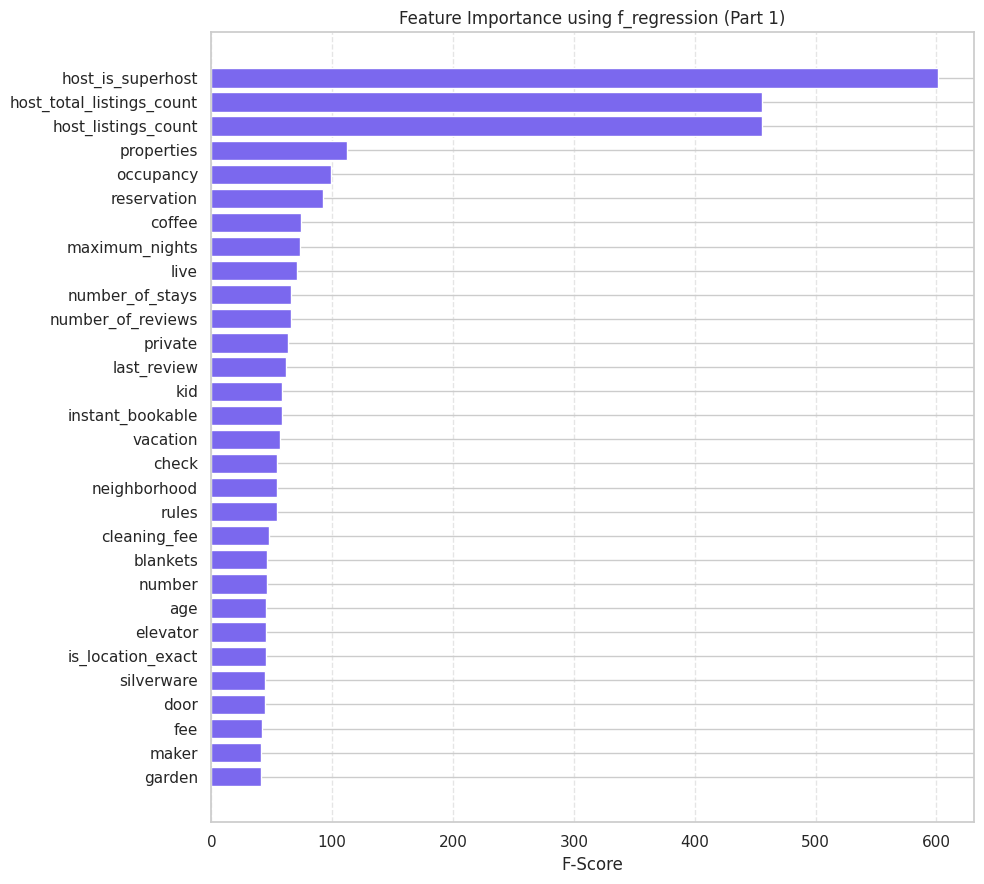

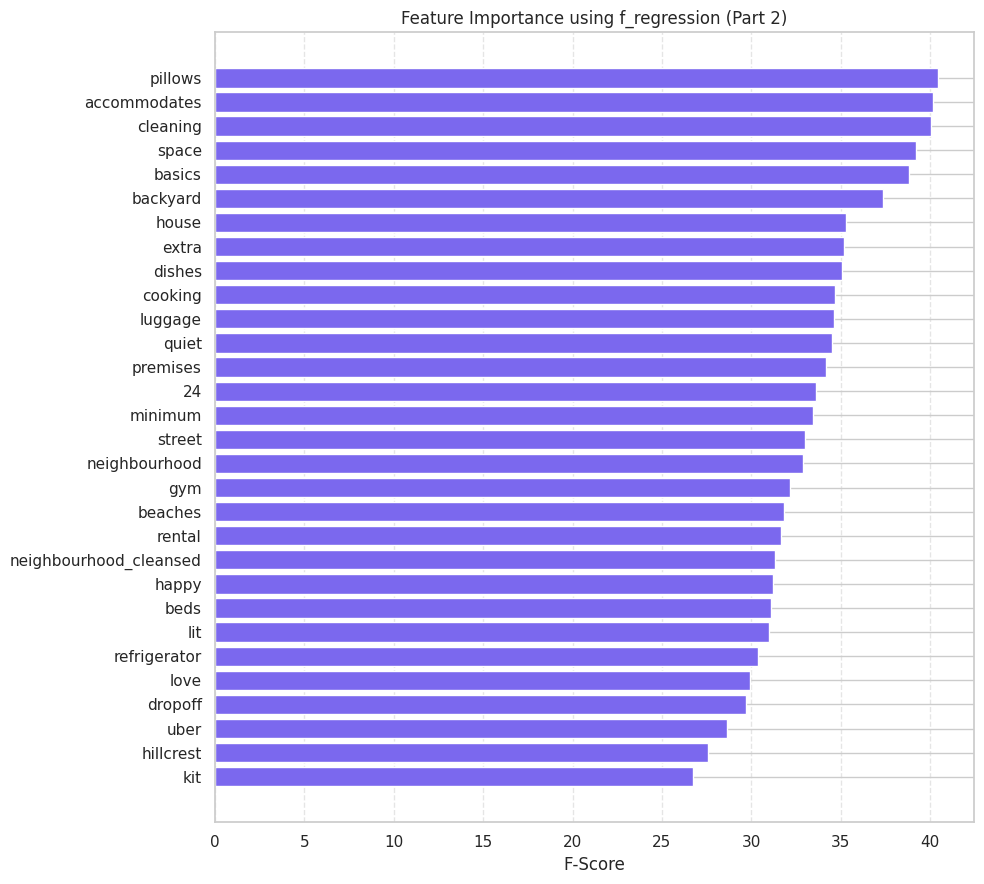

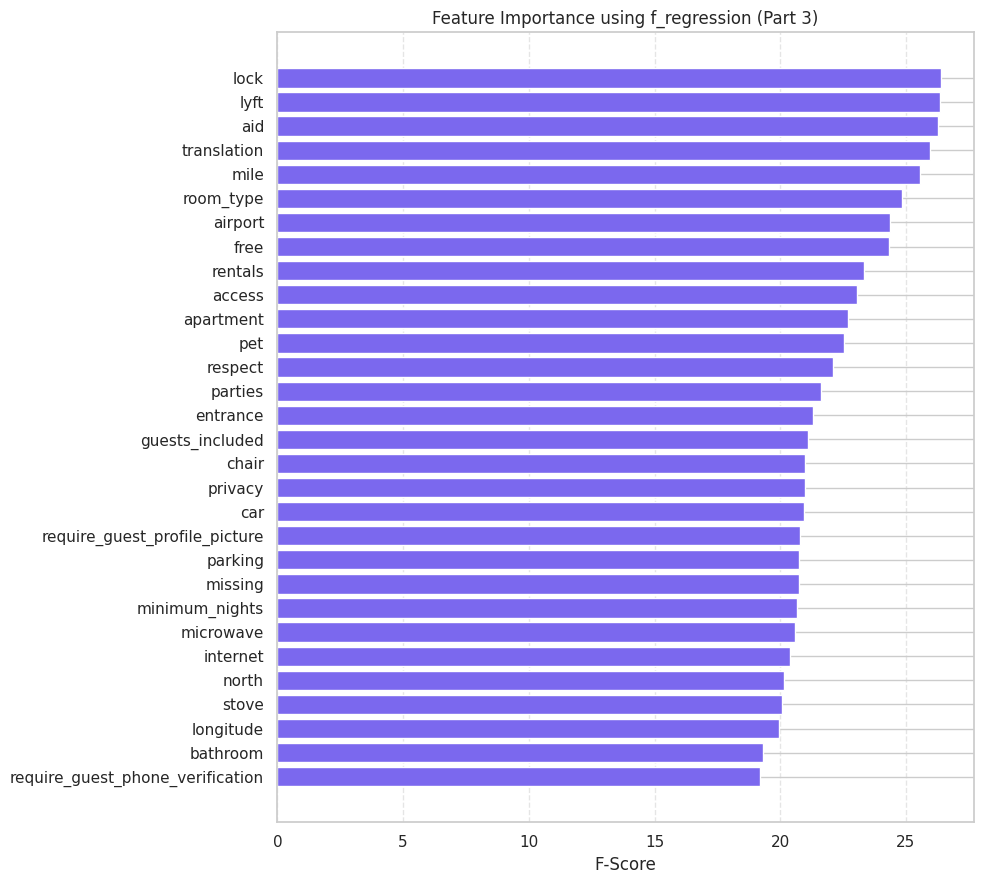

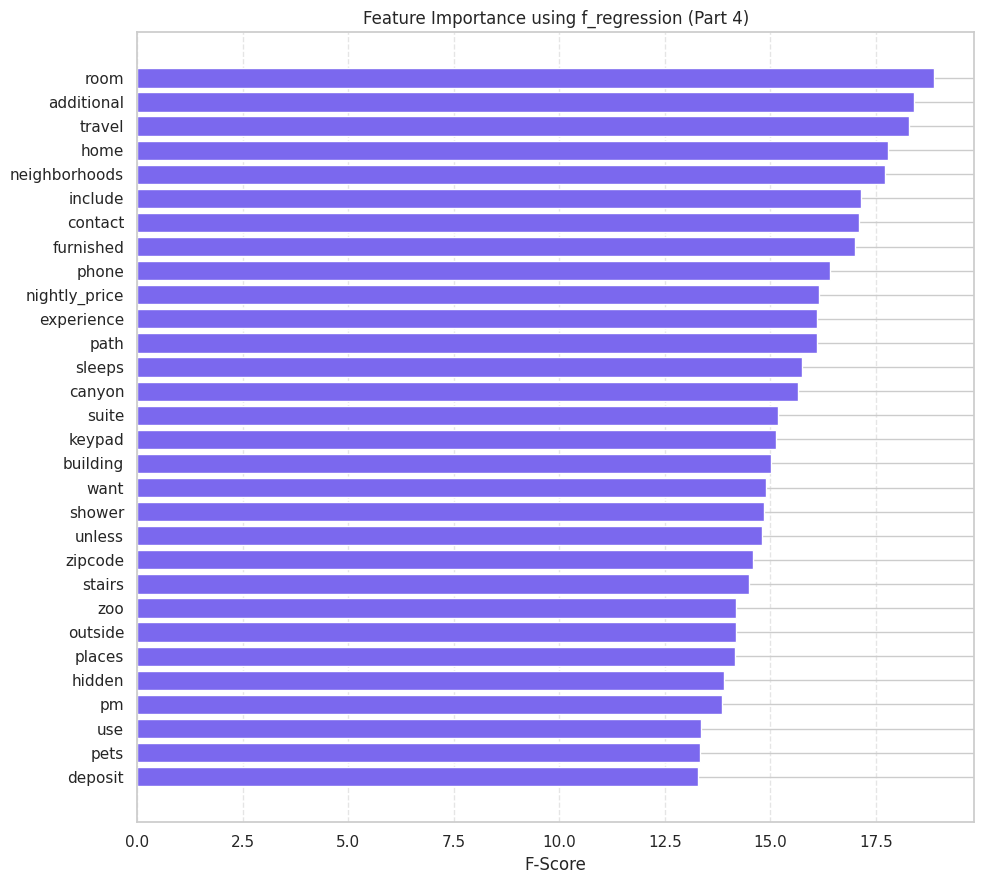

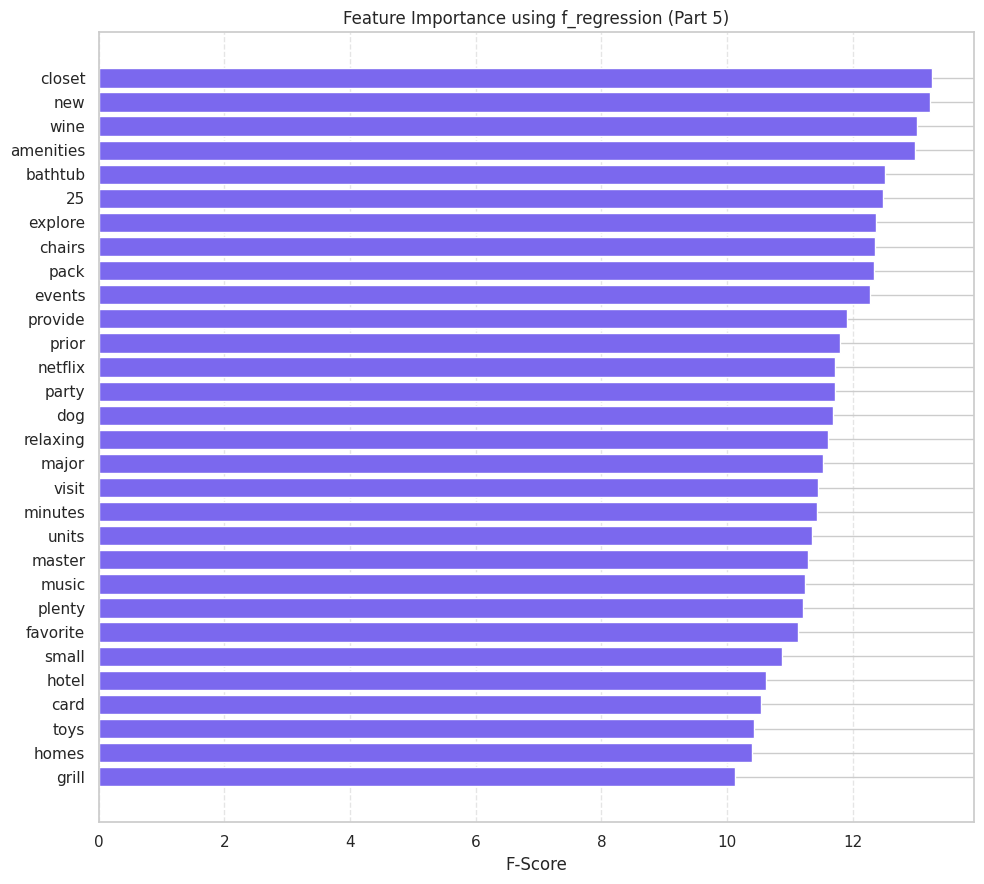

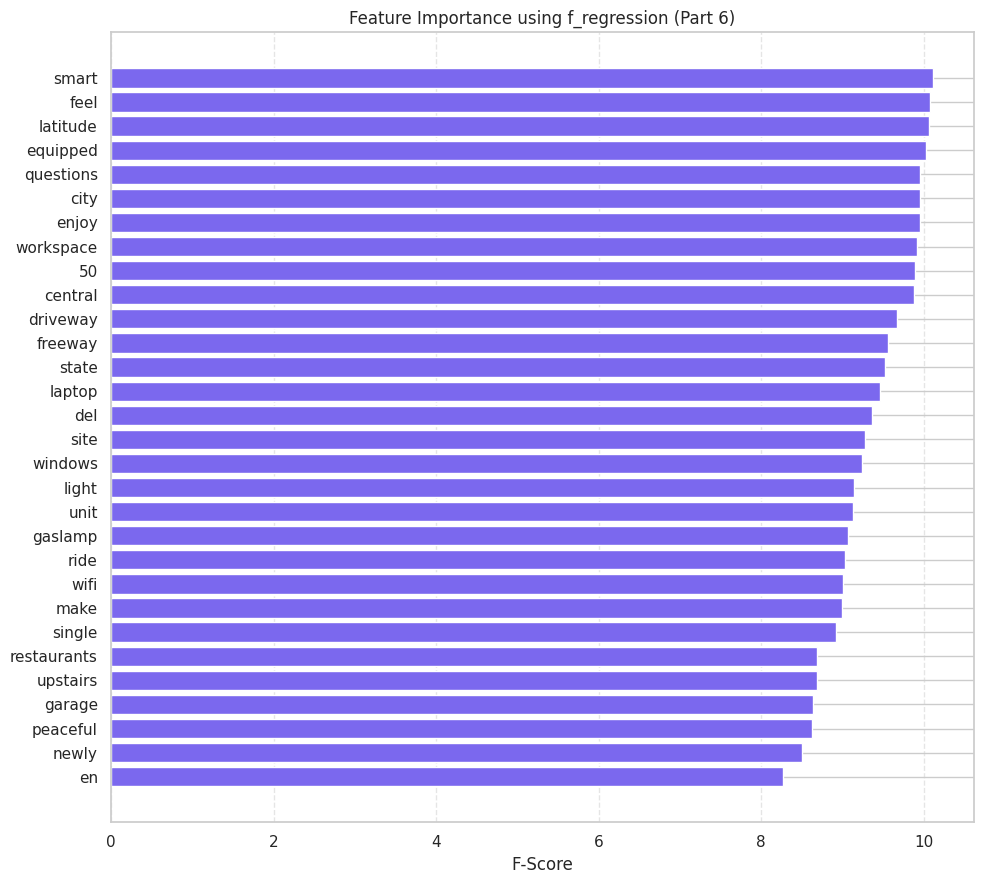

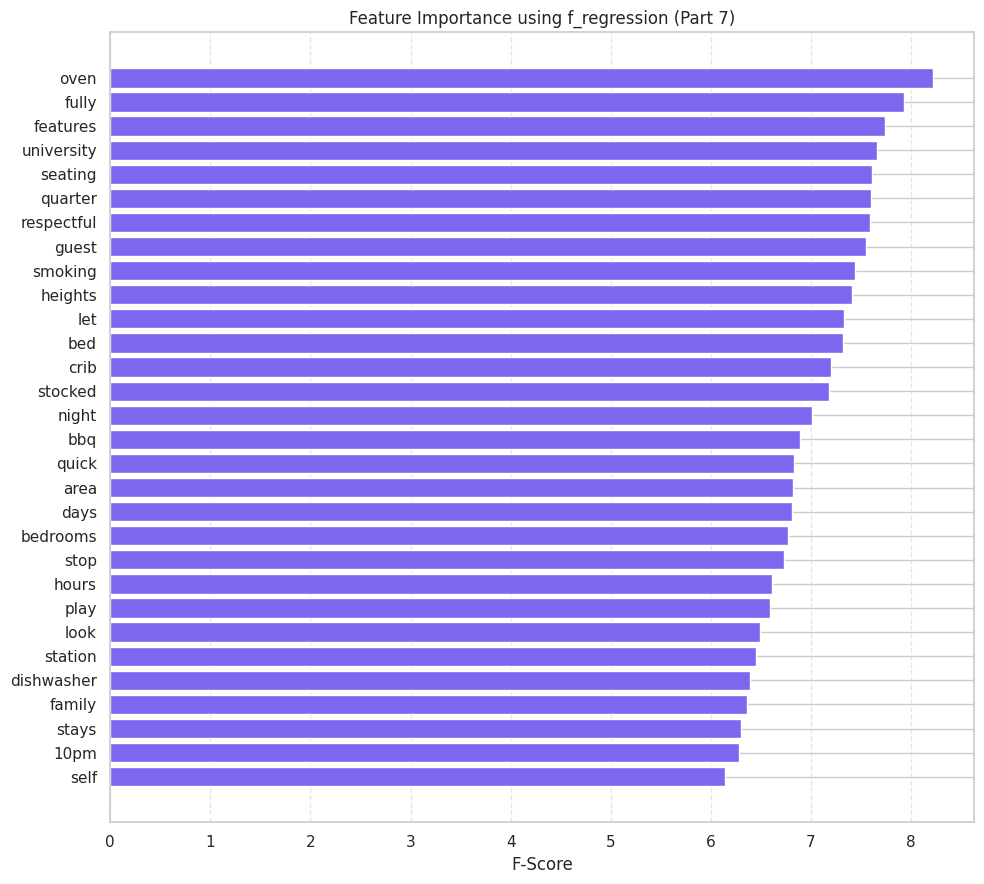

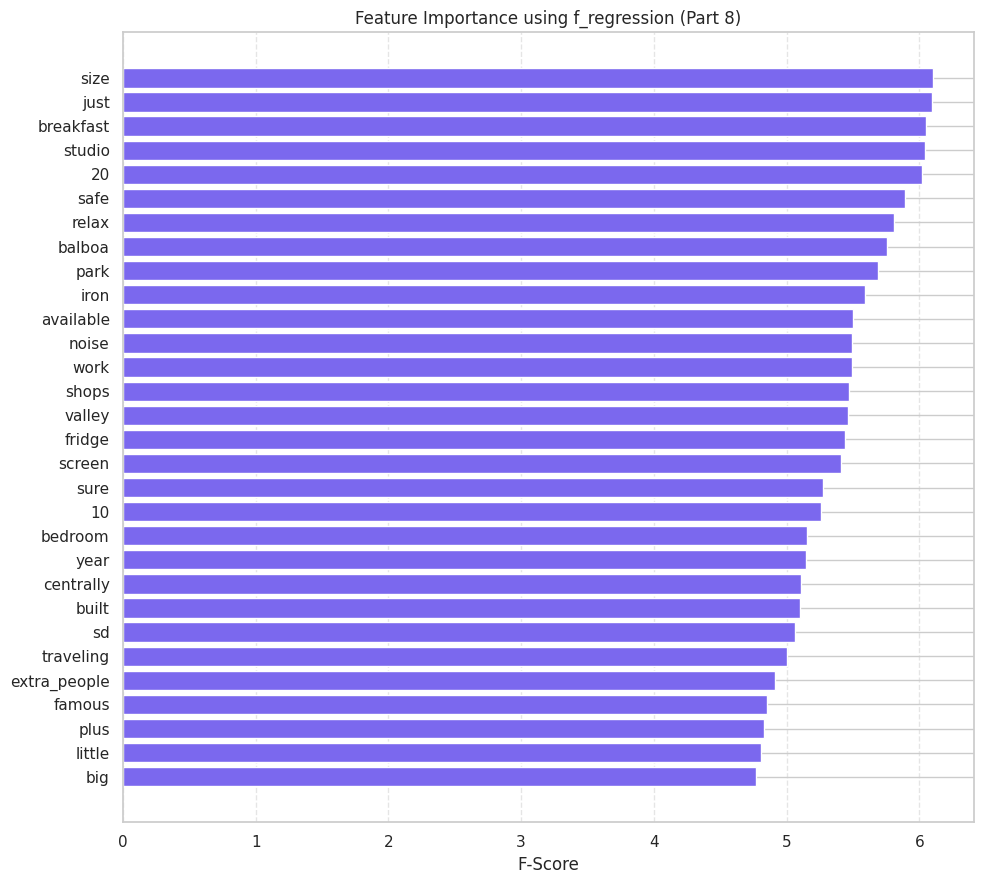

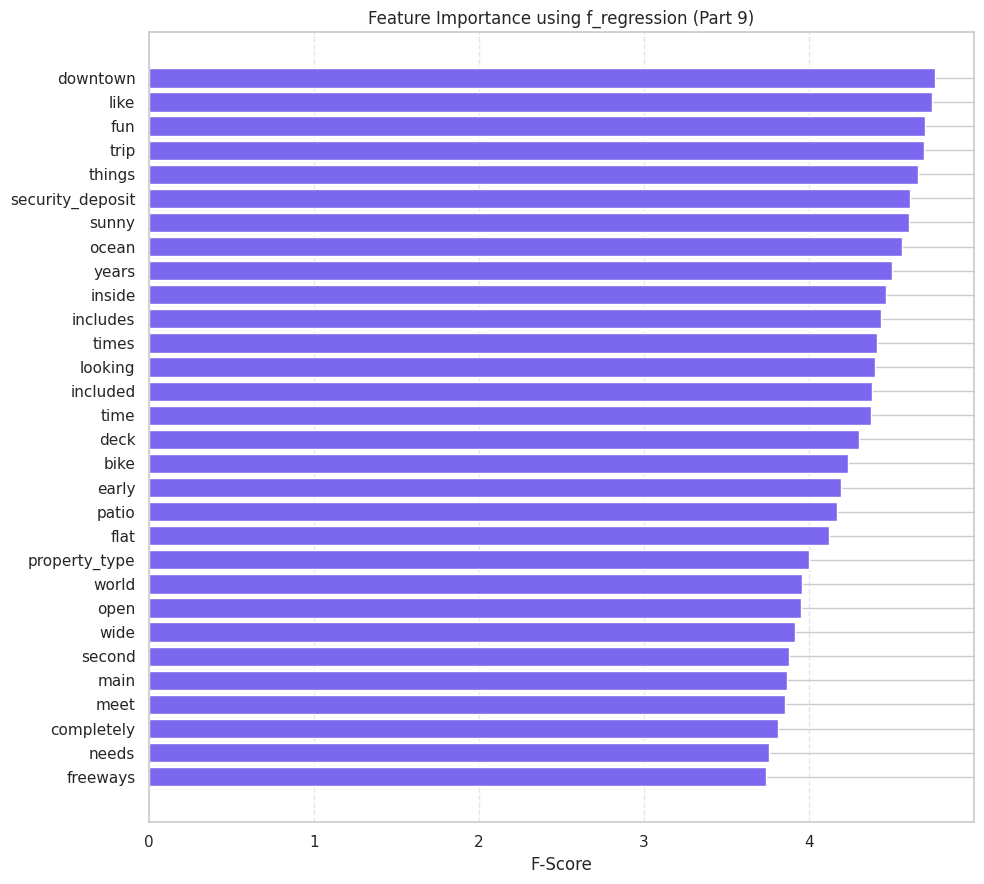

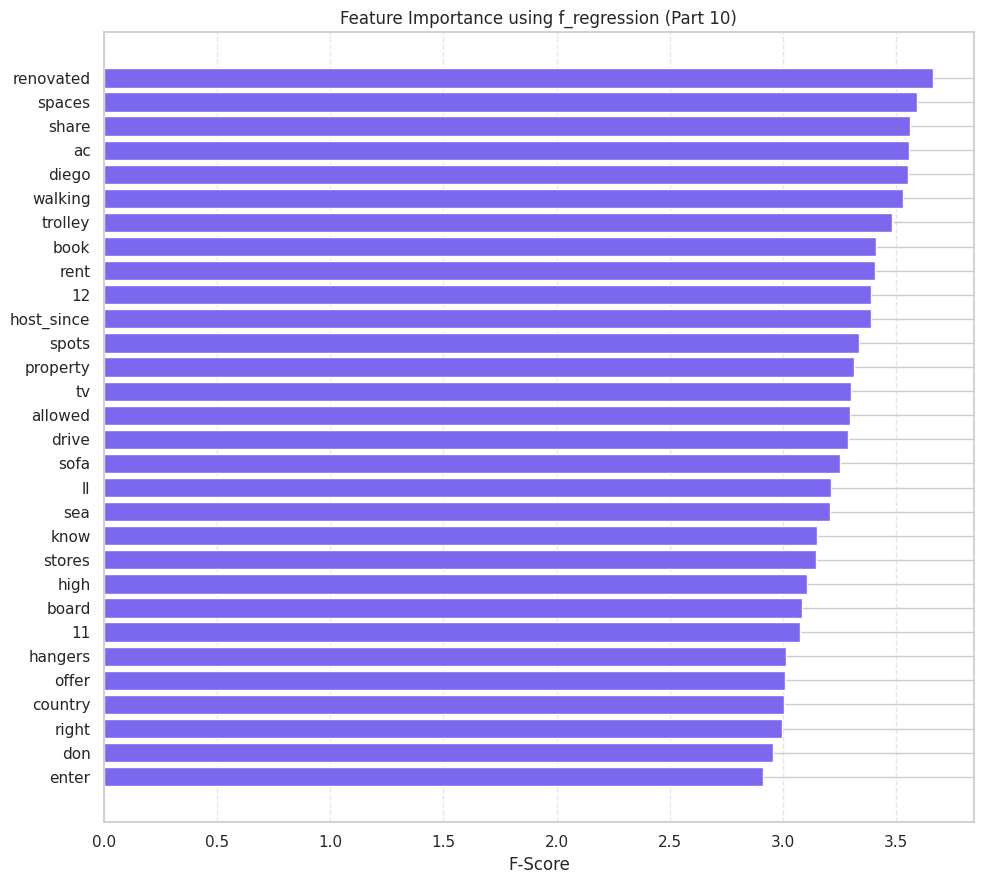

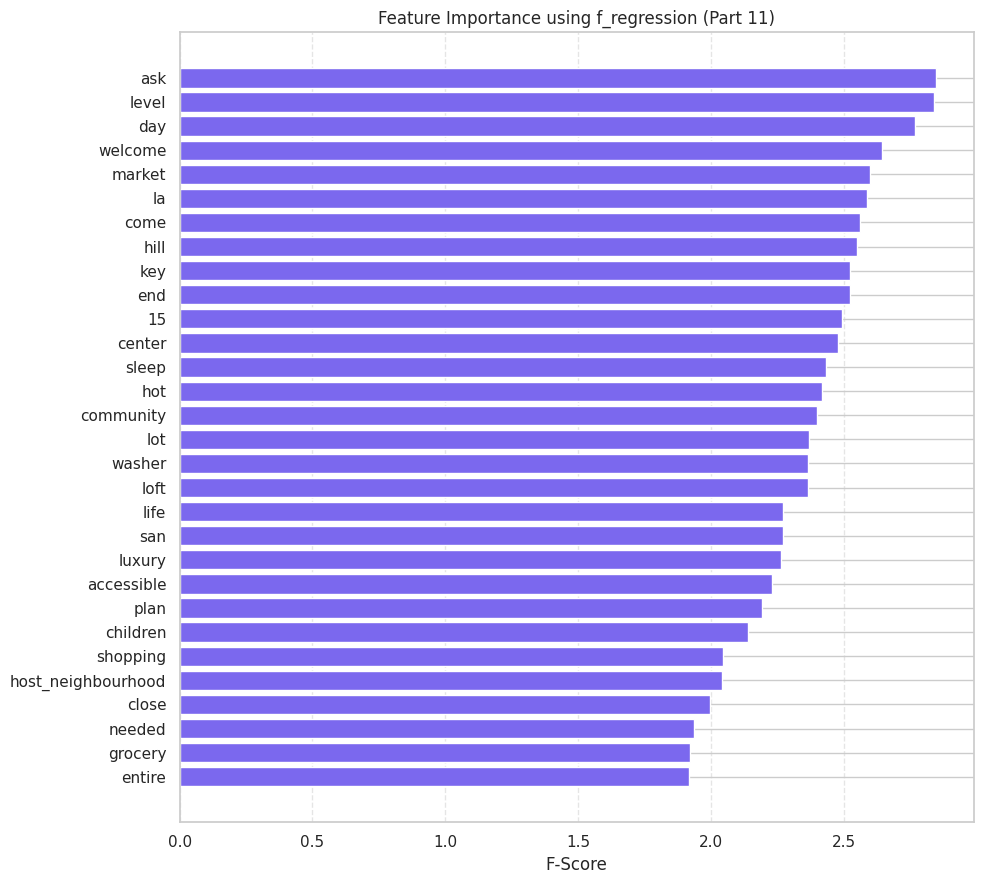

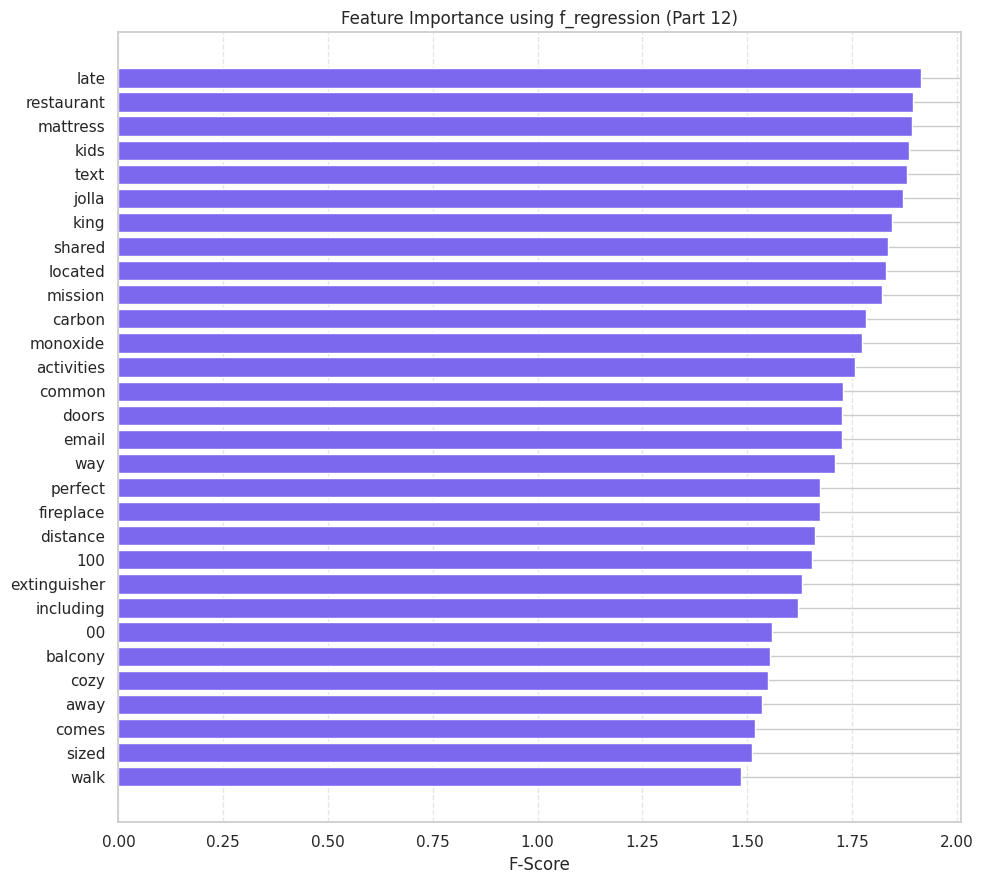

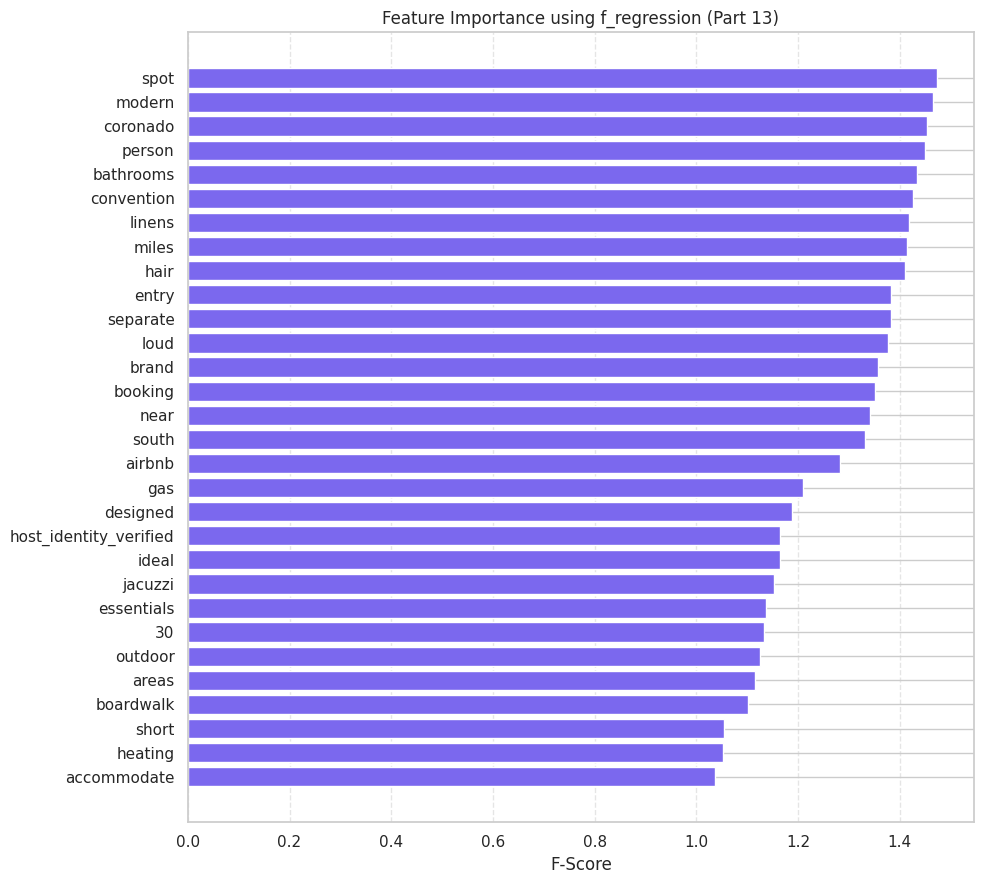

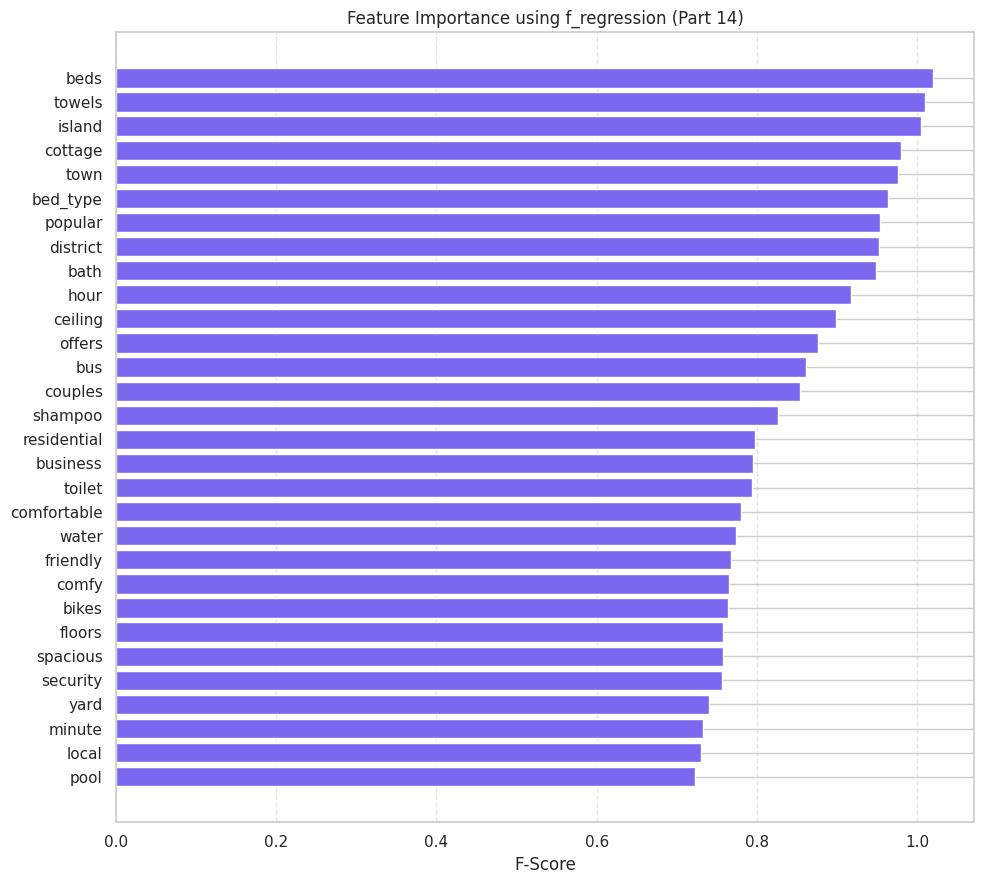

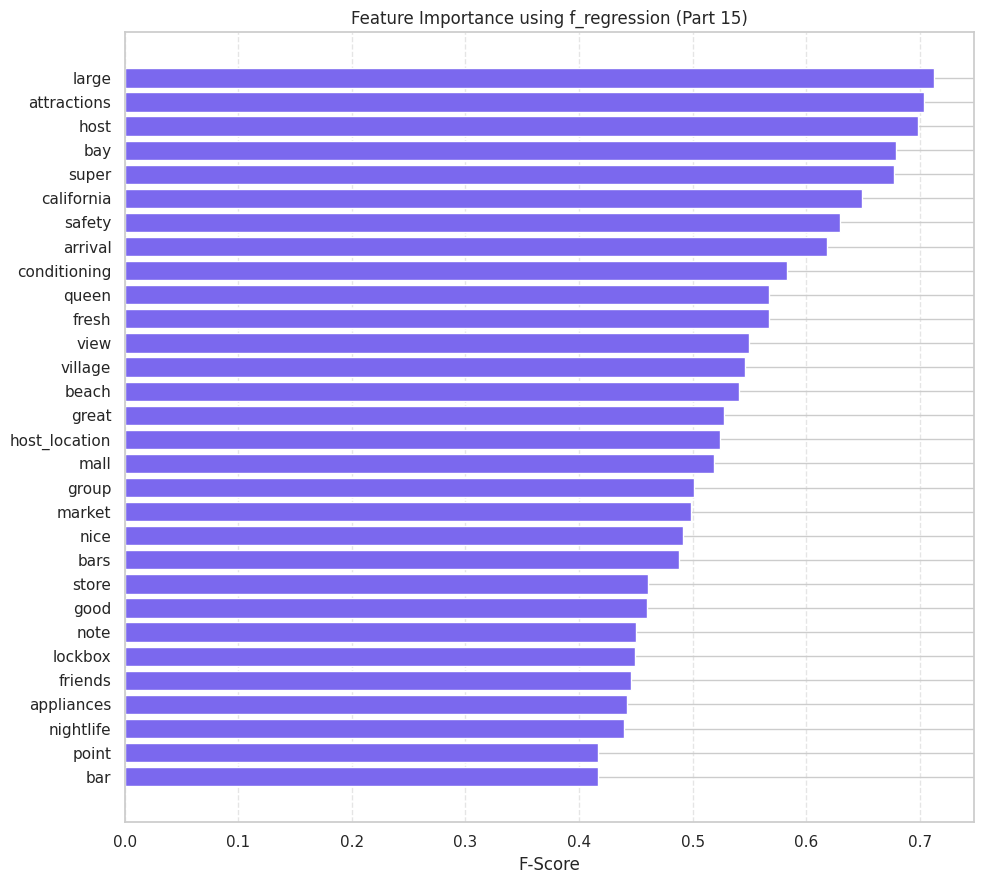

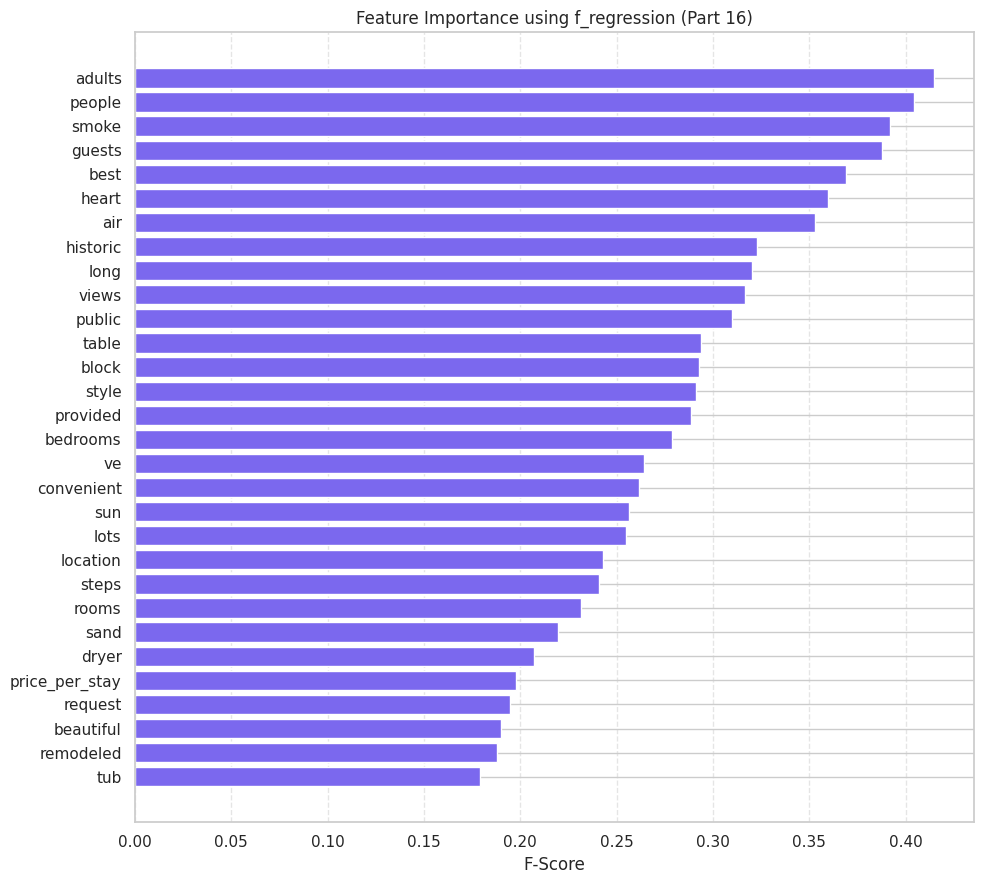

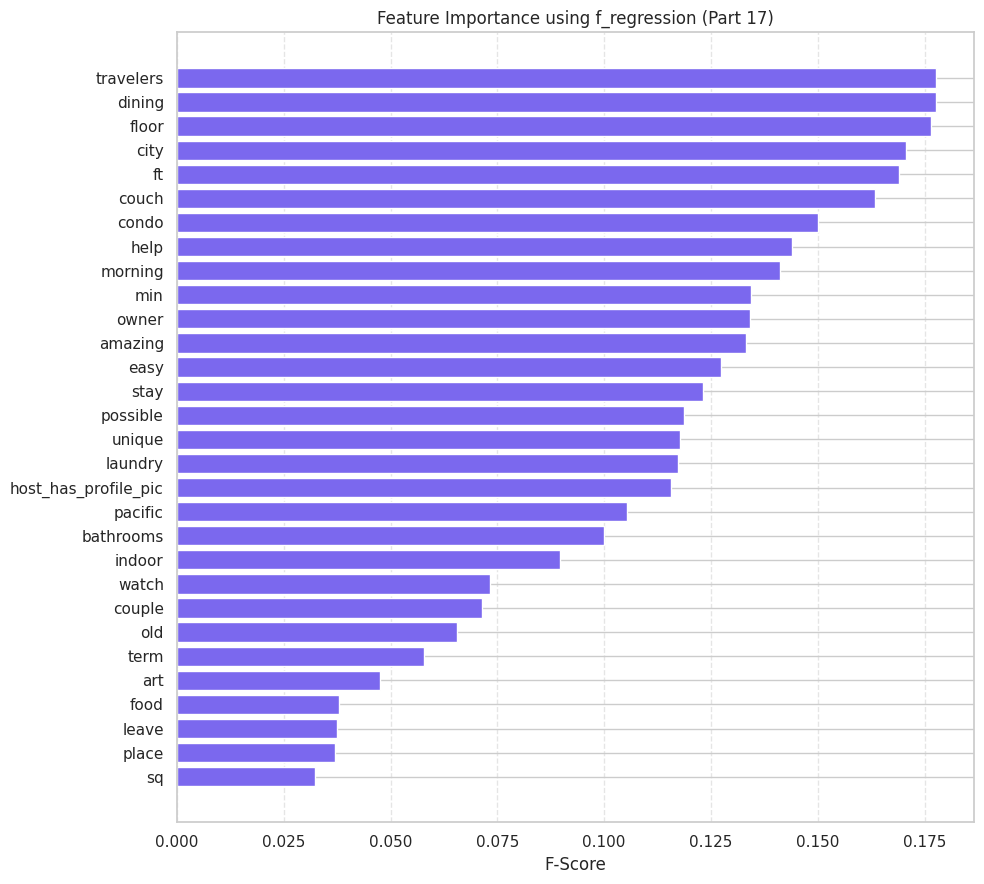

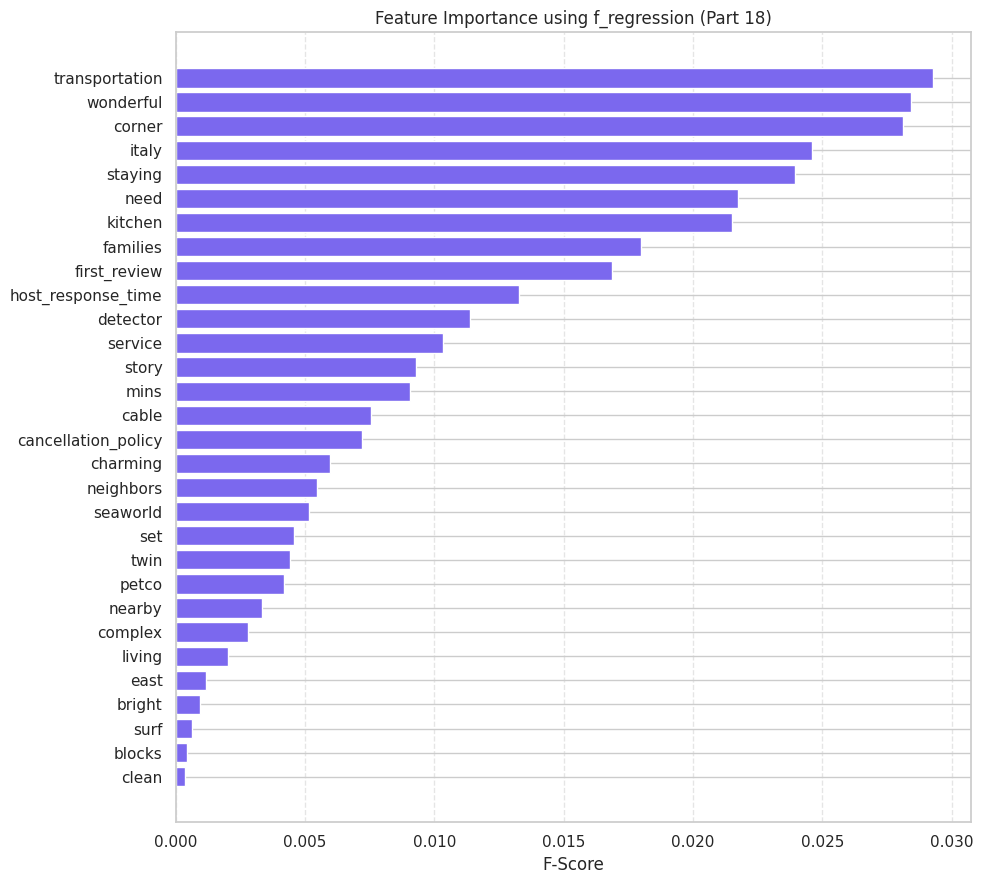

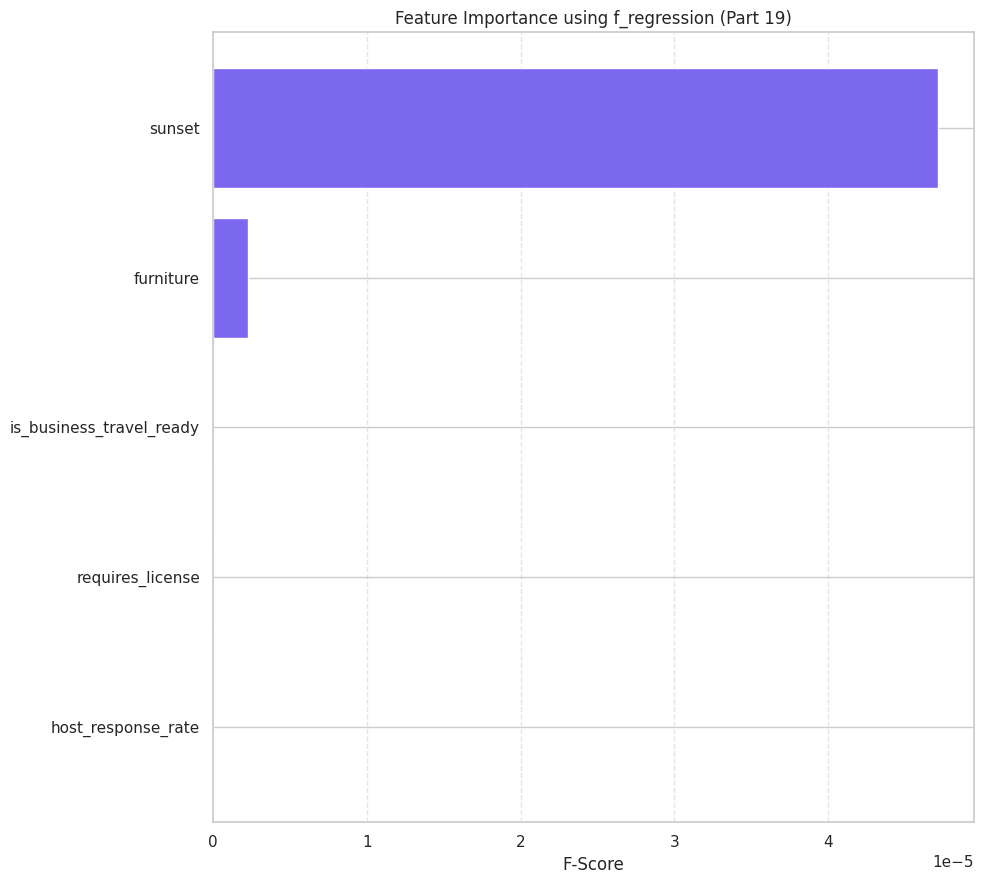

In [67]:
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

X = data.drop(['review_scores_rating'], axis=1)
y = data['review_scores_rating']

X_numeric = X.select_dtypes(include=[np.number])

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_numeric, y)

scores = selector.scores_
features = X_numeric.columns

score_df = pd.DataFrame({'Feature': features, 'F_Score': scores})
score_df = score_df.sort_values(by='F_Score', ascending=False)

print(score_df)


features_per_plot = 30

num_plots = math.ceil(len(score_df) / features_per_plot)

for i in range(num_plots):
    start = i * features_per_plot
    end = start + features_per_plot
    subset = score_df.iloc[start:end]

    plt.figure(figsize=(10, features_per_plot * 0.3))
    plt.barh(subset['Feature'], subset['F_Score'], color='mediumslateblue')
    plt.xlabel('F-Score')
    plt.title(f'Feature Importance using f_regression (Part {i+1})')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



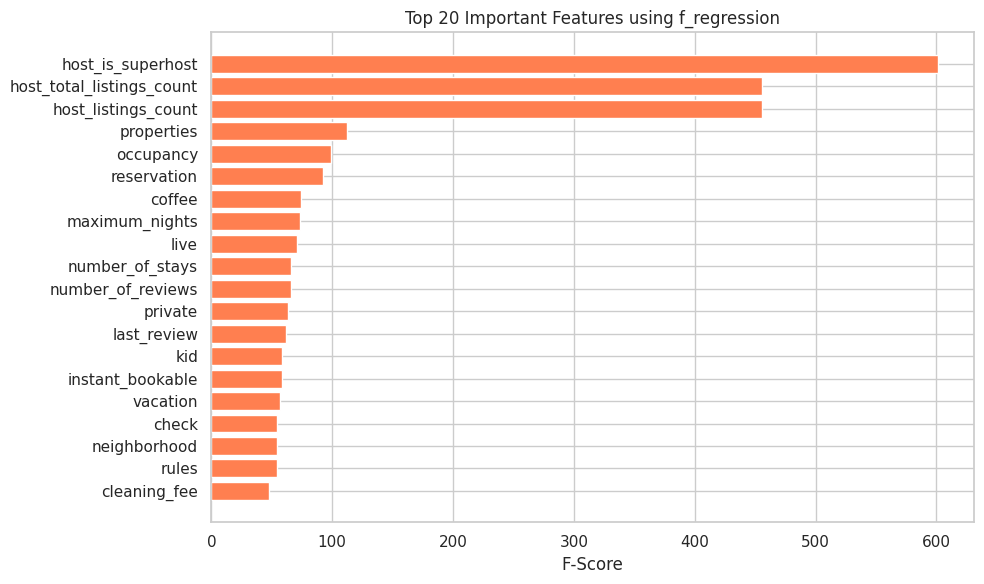

In [68]:
top_20 = score_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_20['Feature'], top_20['F_Score'], color='coral')
plt.xlabel('F-Score')
plt.title('Top 20 Important Features using f_regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [69]:
selector = SelectKBest(score_func=f_regression, k=3)
X_selected = selector.fit_transform(X_numeric, y)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


# PCA

In [70]:
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# X = data.drop(['review_scores_rating'], axis=1)
# y = data['review_scores_rating']
# X_numeric = X.select_dtypes(include=['int64', 'float64'])

# X_filled = X_numeric.fillna(X_numeric.mean())

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_filled)

# pca = PCA()
# X_pca = pca.fit_transform(X_scaled)

# explained_variance = pca.explained_variance_ratio_
# cumulative_variance = np.cumsum(explained_variance)

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
# plt.axhline(y=0.1, color='r', linestyle='--', label='10% Threshold')
# plt.xlabel('Number of Components')
# plt.ylabel('Cumulative Explained Variance')
# plt.title('Choosing the Number of PCA Components')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [71]:
# pca = PCA(n_components=0.1)
# X_pca = pca.fit_transform(X_scaled)
# X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


# REF
زي feature importance


In [72]:
# from sklearn.svm import SVR
# from sklearn.feature_selection import RFECV
# from sklearn.model_selection import train_test_split
# from xgboost import XGBRegressor
# import pandas as pd
# import matplotlib.pyplot as plt
# import lightgbm as lgb
# from sklearn.linear_model import LinearRegression, Lasso
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# # -----------------------------------
# # 1. Split the data
# X = data.drop(['review_scores_rating'], axis=1)
# y = data['review_scores_rating']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # -----------------------------------
# # 2. Feature selection using RFECV with SVR
# svr = SVR(kernel='linear')
# rfecv = RFECV(estimator=svr, step=1, cv=5)
# rfecv.fit(X_train, y_train)

# selected_features_rfecv = X.columns[rfecv.support_]
# print("✅ Selected features using RFECV with SVR:")
# print(selected_features_rfecv)

# # Filter training and test sets with selected features only
# X_train_rfecv = X_train[selected_features_rfecv]
# X_test_rfecv = X_test[selected_features_rfecv]

# # -----------------------------------
# # 3. Define regression models
# models = {
#     'Linear Regression': LinearRegression(),
#     'Lasso Regression': Lasso(),
#     'Decision Tree': DecisionTreeRegressor(),
#     'SVM': SVR(),
#     'XGBoost': XGBRegressor(),
#     'LightGBM': lgb.LGBMRegressor(),
#     'Random Forest': RandomForestRegressor(),
#     'Gradient Boosting': GradientBoostingRegressor()
# }

# # -----------------------------------
# # 4. Train and evaluate models using RFECV-selected features
# results_rfecv = {}

# for model_name, model in models.items():
#     model.fit(X_train_rfecv, y_train)
#     y_pred = model.predict(X_test_rfecv)
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     results_rfecv[model_name] = {'MSE': mse, 'R2': r2}

# # -----------------------------------
# # 5. Display results
# results_rfecv_df = pd.DataFrame(results_rfecv).T
# print("\n📊 Model performance using RFECV-selected features:")
# print(results_rfecv_df)


# Feature Importance
(بتاخد وقت كبير جدا لو ظبطنا preposessing نبقى نجربها و نضيفها في الريبورت)






In [73]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression, Lasso
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.svm import SVR
# from sklearn.ensemble import GradientBoostingRegressor
# import lightgbm as lgb
# from sklearn.metrics import mean_squared_error, r2_score
# import pandas as pd
# import matplotlib.pyplot as plt

# # -------------------------------------
# # 1. Split the data
# # -------------------------------------
# X = data.drop(['review_scores_rating'], axis=1)
# y = data['review_scores_rating']

# # Ensure we only keep numerical columns (int64, float64)
# X_numeric = X.select_dtypes(include=['number'])

# # Verify column data types after selection
# print(X_numeric.dtypes)  # Print data types of the columns in X_numeric

# # Check for any non-numeric columns left
# non_numeric_columns = X_numeric.select_dtypes(exclude=['number']).columns
# print("Non-numeric columns left:", non_numeric_columns)

# # Check for any missing or infinite values
# print("Checking for NaN or Inf values...")
# print(X_numeric.isnull().sum())  # Print number of missing values per column
# print((X_numeric == float('inf')).sum())  # Check for infinity values

# # Handle missing or infinite values (if any)
# X_numeric = X_numeric.fillna(X_numeric.mean())  # Fill NaN with mean for each column
# X_numeric = X_numeric.replace([float('inf'), -float('inf')], 0)  # Replace infinity with 0

# # Split the data into train and test
# X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)

# # -------------------------------------
# # 2. Feature selection using Random Forest importance
# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

# # Get feature importances and sort them
# feature_importances = rf_model.feature_importances_
# feature_df = pd.DataFrame({
#     'Feature': X_numeric.columns,  # Use X_numeric columns here
#     'Importance': feature_importances
# }).sort_values(by='Importance', ascending=False)

# # Optional: Visualize
# plt.figure(figsize=(10, 6))
# plt.barh(feature_df['Feature'], feature_df['Importance'])
# plt.xlabel('Feature Importance')
# plt.title('Feature Importance using Random Forest')
# plt.gca().invert_yaxis()
# plt.show()

# # Select top features (e.g., all non-zero importance)
# selected_features_rf = feature_df[feature_df['Importance'] > 0]['Feature']
# print("✅ Selected features using Random Forest importance:")
# print(selected_features_rf)

# # Filter training and test sets
# X_train_rf = X_train[selected_features_rf]
# X_test_rf = X_test[selected_features_rf]

# # -------------------------------------
# # 3. Define models
# models = {
#     'Linear Regression': LinearRegression(),
#     'Lasso Regression': Lasso(),
#     'Decision Tree': DecisionTreeRegressor(),
#     'SVM': SVR(),
#     'Random Forest': RandomForestRegressor(),
#     'LightGBM': lgb.LGBMRegressor(),
#     'Gradient Boosting': GradientBoostingRegressor()
# }

# # -------------------------------------
# # 4. Train and evaluate models
# results_rf = {}

# for model_name, model in models.items():
#     model.fit(X_train_rf, y_train)
#     y_pred = model.predict(X_test_rf)
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     results_rf[model_name] = {'MSE': mse, 'R2': r2}

# # -------------------------------------
# # 5. Display results
# results_rf_df = pd.DataFrame(results_rf).T
# print("\n📊 Model performance using Random Forest-selected features:")
# print(results_rf_df)


# mutual_info_regression

In [74]:
# from sklearn.feature_selection import mutual_info_regression
# import pandas as pd
# import math

# import numpy as np
# import matplotlib.pyplot as plt
# X = data.drop(['review_scores_rating'], axis=1)
# y = data['review_scores_rating']

# X_numeric = X.select_dtypes(include=[np.number])

# mi = mutual_info_regression(X_numeric, y)
# mi_df = pd.DataFrame({'Feature': X_numeric.columns, 'Mutual Information': mi})
# mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

# top_10 = mi_df.head(10)
# plt.figure(figsize=(10, 5))
# plt.barh(top_10['Feature'], top_10['Mutual Information'], color='mediumseagreen')
# plt.xlabel('Mutual Information')
# plt.title('Top 10 Features (Mutual Information)')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

# remaining_df = mi_df.iloc[10:]
# batch_size = 30
# num_batches = math.ceil(len(remaining_df) / batch_size)

# for i in range(num_batches):
#     batch = remaining_df.iloc[i*batch_size:(i+1)*batch_size]

#     plt.figure(figsize=(10, 6))
#     plt.barh(batch['Feature'], batch['Mutual Information'], color='cornflowerblue')
#     plt.xlabel('Mutual Information')
#     plt.title(f'Features Batch {i+1} (Mutual Information)')
#     plt.gca().invert_yaxis()
#     plt.tight_layout()
#     plt.show()
# top_features = mi_df['Feature'].head(6).tolist()
# X_selected = X_numeric[top_features]

# X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)



# Models

🔍 Running GridSearch for: Linear Regression


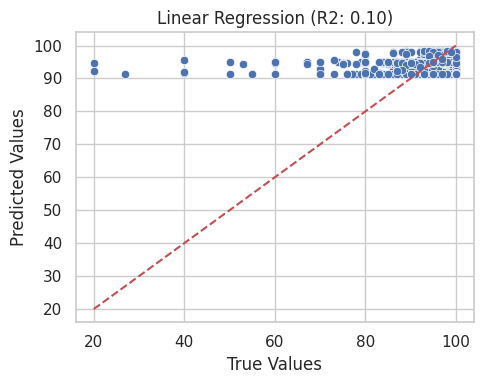

🔍 Running GridSearch for: Lasso Regression


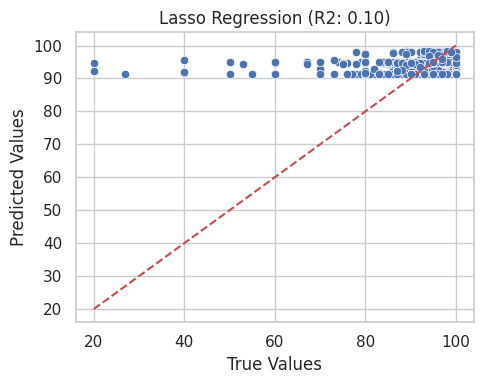

🔍 Running GridSearch for: Decision Tree


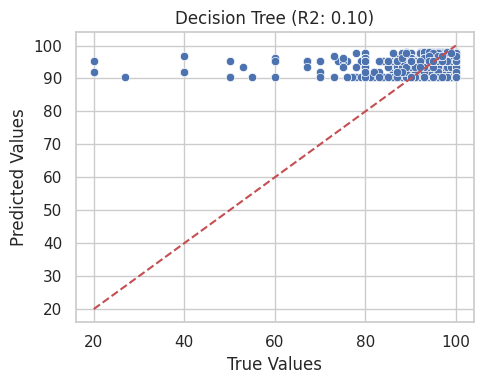

🔍 Running GridSearch for: SVM


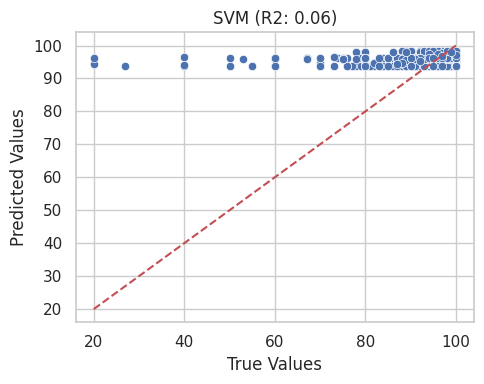

🔍 Running GridSearch for: XGBoost


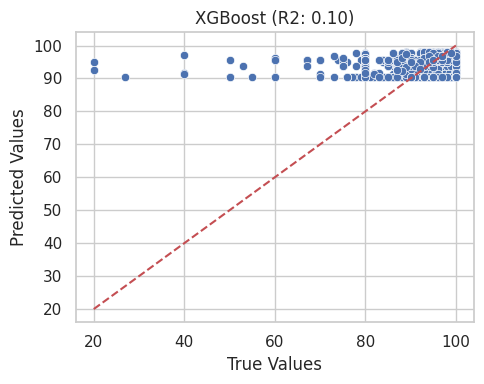

🔍 Running GridSearch for: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 46
[LightGBM] [Info] Number of data points in the train set: 6979, number of used features: 3
[LightGBM] [Info] Start training from score 95.323685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


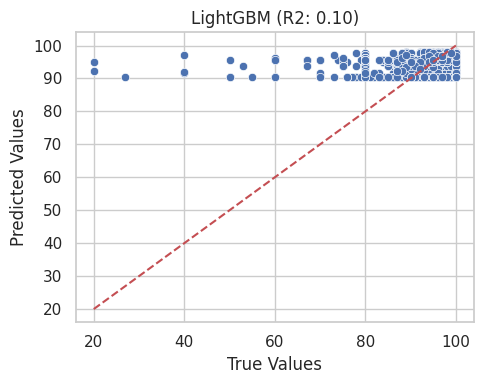

🔍 Running GridSearch for: Random Forest


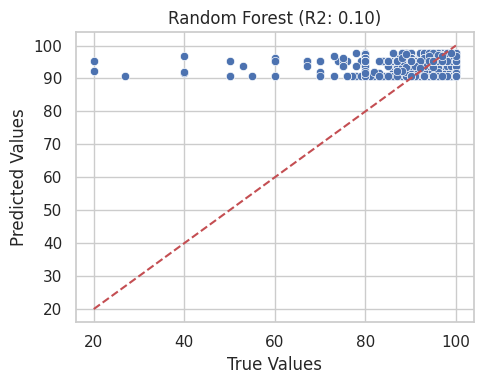

🔍 Running GridSearch for: Gradient Boosting


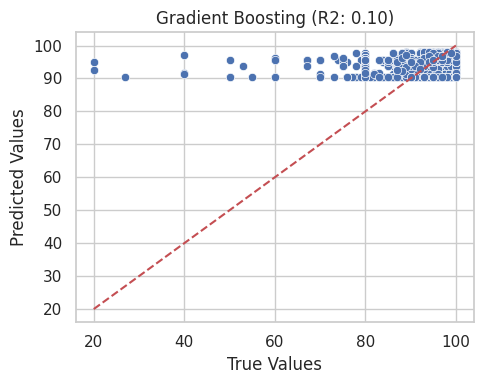


📊 Final Results with Best Params:
                                                         Best Params  \
Linear Regression                                                 {}   
Lasso Regression                                    {'alpha': 0.001}   
Decision Tree               {'max_depth': 3, 'min_samples_split': 2}   
SVM                                    {'C': 10, 'kernel': 'linear'}   
XGBoost            {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...   
LightGBM           {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...   
Random Forest                   {'max_depth': 3, 'n_estimators': 50}   
Gradient Boosting  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...   

                         MSE        R2  
Linear Regression  47.847771  0.104649  
Lasso Regression   47.847409  0.104656  
Decision Tree      47.893925  0.103785  
SVM                50.152591   0.06152  
XGBoost            47.864261   0.10434  
LightGBM           47.902239   0.10363  
Random Forest      47.891354 

In [75]:
import lightgbm as lgb
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Models and their parameter grids
models_params = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'Lasso Regression': {
        'model': Lasso(),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1, 10]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(),
        'params': {
            'max_depth': [3, 5, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    },
    'SVM': {
        'model': SVR(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
    },
    'XGBoost': {
        'model': XGBRegressor(),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5, -1],
            'learning_rate': [0.01, 0.1]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5, 10]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1]
        }
    }
}

results_grid = {}

for name, config in models_params.items():
    print(f"🔍 Running GridSearch for: {name}")
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results_grid[name] = {
        'Best Params': grid.best_params_,
        'MSE': mse,
        'R2': r2
    }

    # Visualization: True vs Predicted
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f"{name} (R2: {r2:.2f})")
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results_grid).T
print("\n📊 Final Results with Best Params:")
print(results_df)
